# **Project Assignment \#5 - Evaluation of Hill Climbing and Simulated Annealing on 8-Puzzle and 8-Queens**

<br>

**University of Puerto Rico, Mayagüez Campus**  
**Electrical and Computer Engineering Department**

---

<br>

### Prepared by:
Jael A. Gonzalez De Arce  
Néstor O. Santos Torres  
Jayson D. Perez Ramirez  

# How to Run the Notebook

To execute the notebook, run all cells sequentially from top to bottom.

It is important to first execute the cells containing the Berkeley-provided modules, as they define the necessary search algorithms and supporting functions used throughout the notebook.

Once these modules are loaded, the remaining cells can be run in order to reproduce all results, including path computations, visualizations, and performance outputs.


The following external libraries may need to be installed before running the notebook:

- numpy
- matplotlib
- pandas

# Report

The report for the assignment is found as the last part of the notebook.

**Note on Figures and Tables Rendering:**  
The specifications for this project require the inclusion and referencing of tables and figures within the report. This document was developed using Google Colaboratory, which encodes images (figures and tables) in Base64 format to ensure they are embedded directly in the file. Under normal conditions, these elements should render correctly in supported environments. If any issues arise with the visualization of figures or tables, please contact the authors so that the corresponding images can be provided separately.

# UC Berkeley Modules
The following blocks include the utils.py and search.py modules from the UC Berkeley AIMA Python repository. These provide the core data structures and search algorithms (such as our NQueensProblem) used in this assignment.

In [ ]:
#utils.py from Berkeley repository
"""Provides some utilities widely used by other modules"""

import bisect
import collections
import collections.abc
import functools
import heapq
import operator
import os.path
import random
from itertools import chain, combinations
from statistics import mean

import numpy as np


# ______________________________________________________________________________
# Functions on Sequences and Iterables


def sequence(iterable):
    """Converts iterable to sequence, if it is not already one."""
    return iterable if isinstance(iterable, collections.abc.Sequence) else tuple([iterable])


def remove_all(item, seq):
    """Return a copy of seq (or string) with all occurrences of item removed."""
    if isinstance(seq, str):
        return seq.replace(item, '')
    elif isinstance(seq, set):
        rest = seq.copy()
        rest.remove(item)
        return rest
    else:
        return [x for x in seq if x != item]


def unique(seq):
    """Remove duplicate elements from seq. Assumes hashable elements."""
    return list(set(seq))


def count(seq):
    """Count the number of items in sequence that are interpreted as true."""
    return sum(map(bool, seq))


def multimap(items):
    """Given (key, val) pairs, return {key: [val, ....], ...}."""
    result = collections.defaultdict(list)
    for (key, val) in items:
        result[key].append(val)
    return dict(result)


def multimap_items(mmap):
    """Yield all (key, val) pairs stored in the multimap."""
    for (key, vals) in mmap.items():
        for val in vals:
            yield key, val


def product(numbers):
    """Return the product of the numbers, e.g. product([2, 3, 10]) == 60"""
    result = 1
    for x in numbers:
        result *= x
    return result


def first(iterable, default=None):
    """Return the first element of an iterable; or default."""
    return next(iter(iterable), default)


def is_in(elt, seq):
    """Similar to (elt in seq), but compares with 'is', not '=='."""
    return any(x is elt for x in seq)


def mode(data):
    """Return the most common data item. If there are ties, return any one of them."""
    [(item, count)] = collections.Counter(data).most_common(1)
    return item


def power_set(iterable):
    """power_set([1,2,3]) --> (1,) (2,) (3,) (1,2) (1,3) (2,3) (1,2,3)"""
    s = list(iterable)
    return list(chain.from_iterable(combinations(s, r) for r in range(len(s) + 1)))[1:]


def extend(s, var, val):
    """Copy dict s and extend it by setting var to val; return copy."""
    return {**s, var: val}


def flatten(seqs):
    return sum(seqs, [])


# ______________________________________________________________________________
# argmin and argmax

identity = lambda x: x


def argmin_random_tie(seq, key=identity):
    """Return a minimum element of seq; break ties at random."""
    return min(shuffled(seq), key=key)


def argmax_random_tie(seq, key=identity):
    """Return an element with highest fn(seq[i]) score; break ties at random."""
    return max(shuffled(seq), key=key)


def shuffled(iterable):
    """Randomly shuffle a copy of iterable."""
    items = list(iterable)
    random.shuffle(items)
    return items


# ______________________________________________________________________________
# Statistical and mathematical functions


def histogram(values, mode=0, bin_function=None):
    """Return a list of (value, count) pairs, summarizing the input values.
    Sorted by increasing value, or if mode=1, by decreasing count.
    If bin_function is given, map it over values first."""
    if bin_function:
        values = map(bin_function, values)

    bins = {}
    for val in values:
        bins[val] = bins.get(val, 0) + 1

    if mode:
        return sorted(list(bins.items()), key=lambda x: (x[1], x[0]), reverse=True)
    else:
        return sorted(bins.items())


def dot_product(x, y):
    """Return the sum of the element-wise product of vectors x and y."""
    return sum(_x * _y for _x, _y in zip(x, y))


def element_wise_product(x, y):
    """Return vector as an element-wise product of vectors x and y."""
    assert len(x) == len(y)
    return np.multiply(x, y)


def matrix_multiplication(x, *y):
    """Return a matrix as a matrix-multiplication of x and arbitrary number of matrices *y."""

    result = x
    for _y in y:
        result = np.matmul(result, _y)

    return result


def vector_add(a, b):
    """Component-wise addition of two vectors."""
    return tuple(map(operator.add, a, b))


def scalar_vector_product(x, y):
    """Return vector as a product of a scalar and a vector"""
    return np.multiply(x, y)


def probability(p):
    """Return true with probability p."""
    return p > random.uniform(0.0, 1.0)


def weighted_sample_with_replacement(n, seq, weights):
    """Pick n samples from seq at random, with replacement, with the
    probability of each element in proportion to its corresponding
    weight."""
    sample = weighted_sampler(seq, weights)
    return [sample() for _ in range(n)]


def weighted_sampler(seq, weights):
    """Return a random-sample function that picks from seq weighted by weights."""
    totals = []
    for w in weights:
        totals.append(w + totals[-1] if totals else w)
    return lambda: seq[bisect.bisect(totals, random.uniform(0, totals[-1]))]


def weighted_choice(choices):
    """A weighted version of random.choice"""
    # NOTE: should be replaced by random.choices if we port to Python 3.6

    total = sum(w for _, w in choices)
    r = random.uniform(0, total)
    upto = 0
    for c, w in choices:
        if upto + w >= r:
            return c, w
        upto += w


def rounder(numbers, d=4):
    """Round a single number, or sequence of numbers, to d decimal places."""
    if isinstance(numbers, (int, float)):
        return round(numbers, d)
    else:
        constructor = type(numbers)  # Can be list, set, tuple, etc.
        return constructor(rounder(n, d) for n in numbers)


def num_or_str(x):  # TODO: rename as `atom`
    """The argument is a string; convert to a number if possible, or strip it."""
    try:
        return int(x)
    except ValueError:
        try:
            return float(x)
        except ValueError:
            return str(x).strip()


def euclidean_distance(x, y):
    return np.sqrt(sum((_x - _y) ** 2 for _x, _y in zip(x, y)))


def manhattan_distance(x, y):
    return sum(abs(_x - _y) for _x, _y in zip(x, y))


def hamming_distance(x, y):
    return sum(_x != _y for _x, _y in zip(x, y))


def cross_entropy_loss(x, y):
    return (-1.0 / len(x)) * sum(_x * np.log(_y) + (1 - _x) * np.log(1 - _y) for _x, _y in zip(x, y))


def mean_squared_error_loss(x, y):
    return (1.0 / len(x)) * sum((_x - _y) ** 2 for _x, _y in zip(x, y))


def rms_error(x, y):
    return np.sqrt(ms_error(x, y))


def ms_error(x, y):
    return mean((_x - _y) ** 2 for _x, _y in zip(x, y))


def mean_error(x, y):
    return mean(abs(_x - _y) for _x, _y in zip(x, y))


def mean_boolean_error(x, y):
    return mean(_x != _y for _x, _y in zip(x, y))


def normalize(dist):
    """Multiply each number by a constant such that the sum is 1.0"""
    if isinstance(dist, dict):
        total = sum(dist.values())
        for key in dist:
            dist[key] = dist[key] / total
            assert 0 <= dist[key] <= 1  # probabilities must be between 0 and 1
        return dist
    total = sum(dist)
    return [(n / total) for n in dist]


def random_weights(min_value, max_value, num_weights):
    return [random.uniform(min_value, max_value) for _ in range(num_weights)]


def sigmoid(x):
    """Return activation value of x with sigmoid function."""
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(value):
    return value * (1 - value)


def elu(x, alpha=0.01):
    return x if x > 0 else alpha * (np.exp(x) - 1)


def elu_derivative(value, alpha=0.01):
    return 1 if value > 0 else alpha * np.exp(value)


def tanh(x):
    return np.tanh(x)


def tanh_derivative(value):
    return 1 - (value ** 2)


def leaky_relu(x, alpha=0.01):
    return x if x > 0 else alpha * x


def leaky_relu_derivative(value, alpha=0.01):
    return 1 if value > 0 else alpha


def relu(x):
    return max(0, x)


def relu_derivative(value):
    return 1 if value > 0 else 0


def step(x):
    """Return activation value of x with sign function"""
    return 1 if x >= 0 else 0


def gaussian(mean, st_dev, x):
    """Given the mean and standard deviation of a distribution, it returns the probability of x."""
    return 1 / (np.sqrt(2 * np.pi) * st_dev) * np.e ** (-0.5 * (float(x - mean) / st_dev) ** 2)


def linear_kernel(x, y=None):
    if y is None:
        y = x
    return np.dot(x, y.T)


def polynomial_kernel(x, y=None, degree=2.0):
    if y is None:
        y = x
    return (1.0 + np.dot(x, y.T)) ** degree


def rbf_kernel(x, y=None, gamma=None):
    """Radial-basis function kernel (aka squared-exponential kernel)."""
    if y is None:
        y = x
    if gamma is None:
        gamma = 1.0 / x.shape[1]  # 1.0 / n_features
    return np.exp(-gamma * (-2.0 * np.dot(x, y.T) +
                            np.sum(x * x, axis=1).reshape((-1, 1)) + np.sum(y * y, axis=1).reshape((1, -1))))


# ______________________________________________________________________________
# Grid Functions


orientations = EAST, NORTH, WEST, SOUTH = [(1, 0), (0, 1), (-1, 0), (0, -1)]
turns = LEFT, RIGHT = (+1, -1)


def turn_heading(heading, inc, headings=orientations):
    return headings[(headings.index(heading) + inc) % len(headings)]


def turn_right(heading):
    return turn_heading(heading, RIGHT)


def turn_left(heading):
    return turn_heading(heading, LEFT)


def distance(a, b):
    """The distance between two (x, y) points."""
    xA, yA = a
    xB, yB = b
    return np.hypot((xA - xB), (yA - yB))


def distance_squared(a, b):
    """The square of the distance between two (x, y) points."""
    xA, yA = a
    xB, yB = b
    return (xA - xB) ** 2 + (yA - yB) ** 2


# ______________________________________________________________________________
# Misc Functions

class injection:
    """Dependency injection of temporary values for global functions/classes/etc.
    E.g., `with injection(DataBase=MockDataBase): ...`"""

    def __init__(self, **kwds):
        self.new = kwds

    def __enter__(self):
        self.old = {v: globals()[v] for v in self.new}
        globals().update(self.new)

    def __exit__(self, type, value, traceback):
        globals().update(self.old)


def memoize(fn, slot=None, maxsize=32):
    """Memoize fn: make it remember the computed value for any argument list.
    If slot is specified, store result in that slot of first argument.
    If slot is false, use lru_cache for caching the values."""
    if slot:
        def memoized_fn(obj, *args):
            if hasattr(obj, slot):
                return getattr(obj, slot)
            else:
                val = fn(obj, *args)
                setattr(obj, slot, val)
                return val
    else:
        @functools.lru_cache(maxsize=maxsize)
        def memoized_fn(*args):
            return fn(*args)

    return memoized_fn


def name(obj):
    """Try to find some reasonable name for the object."""
    return (getattr(obj, 'name', 0) or getattr(obj, '__name__', 0) or
            getattr(getattr(obj, '__class__', 0), '__name__', 0) or
            str(obj))


def isnumber(x):
    """Is x a number?"""
    return hasattr(x, '__int__')


def issequence(x):
    """Is x a sequence?"""
    return isinstance(x, collections.abc.Sequence)


def print_table(table, header=None, sep='   ', numfmt='{}'):
    """Print a list of lists as a table, so that columns line up nicely.
    header, if specified, will be printed as the first row.
    numfmt is the format for all numbers; you might want e.g. '{:.2f}'.
    (If you want different formats in different columns,
    don't use print_table.) sep is the separator between columns."""
    justs = ['rjust' if isnumber(x) else 'ljust' for x in table[0]]

    if header:
        table.insert(0, header)

    table = [[numfmt.format(x) if isnumber(x) else x for x in row]
             for row in table]

    sizes = list(map(lambda seq: max(map(len, seq)), list(zip(*[map(str, row) for row in table]))))

    for row in table:
        print(sep.join(getattr(str(x), j)(size) for (j, size, x) in zip(justs, sizes, row)))


def open_data(name, mode='r'):
    aima_root = os.path.dirname(__file__)
    aima_file = os.path.join(aima_root, *['aima-data', name])

    return open(aima_file, mode=mode)


def failure_test(algorithm, tests):
    """Grades the given algorithm based on how many tests it passes.
    Most algorithms have arbitrary output on correct execution, which is difficult
    to check for correctness. On the other hand, a lot of algorithms output something
    particular on fail (for example, False, or None).
    tests is a list with each element in the form: (values, failure_output)."""
    return mean(int(algorithm(x) != y) for x, y in tests)


# ______________________________________________________________________________
# Expressions

# See https://docs.python.org/3/reference/expressions.html#operator-precedence
# See https://docs.python.org/3/reference/datamodel.html#special-method-names

class Expr:
    """A mathematical expression with an operator and 0 or more arguments.
    op is a str like '+' or 'sin'; args are Expressions.
    Expr('x') or Symbol('x') creates a symbol (a nullary Expr).
    Expr('-', x) creates a unary; Expr('+', x, 1) creates a binary."""

    def __init__(self, op, *args):
        self.op = str(op)
        self.args = args

    # Operator overloads
    def __neg__(self):
        return Expr('-', self)

    def __pos__(self):
        return Expr('+', self)

    def __invert__(self):
        return Expr('~', self)

    def __add__(self, rhs):
        return Expr('+', self, rhs)

    def __sub__(self, rhs):
        return Expr('-', self, rhs)

    def __mul__(self, rhs):
        return Expr('*', self, rhs)

    def __pow__(self, rhs):
        return Expr('**', self, rhs)

    def __mod__(self, rhs):
        return Expr('%', self, rhs)

    def __and__(self, rhs):
        return Expr('&', self, rhs)

    def __xor__(self, rhs):
        return Expr('^', self, rhs)

    def __rshift__(self, rhs):
        return Expr('>>', self, rhs)

    def __lshift__(self, rhs):
        return Expr('<<', self, rhs)

    def __truediv__(self, rhs):
        return Expr('/', self, rhs)

    def __floordiv__(self, rhs):
        return Expr('//', self, rhs)

    def __matmul__(self, rhs):
        return Expr('@', self, rhs)

    def __or__(self, rhs):
        """Allow both P | Q, and P |'==>'| Q."""
        if isinstance(rhs, Expression):
            return Expr('|', self, rhs)
        else:
            return PartialExpr(rhs, self)

    # Reverse operator overloads
    def __radd__(self, lhs):
        return Expr('+', lhs, self)

    def __rsub__(self, lhs):
        return Expr('-', lhs, self)

    def __rmul__(self, lhs):
        return Expr('*', lhs, self)

    def __rdiv__(self, lhs):
        return Expr('/', lhs, self)

    def __rpow__(self, lhs):
        return Expr('**', lhs, self)

    def __rmod__(self, lhs):
        return Expr('%', lhs, self)

    def __rand__(self, lhs):
        return Expr('&', lhs, self)

    def __rxor__(self, lhs):
        return Expr('^', lhs, self)

    def __ror__(self, lhs):
        return Expr('|', lhs, self)

    def __rrshift__(self, lhs):
        return Expr('>>', lhs, self)

    def __rlshift__(self, lhs):
        return Expr('<<', lhs, self)

    def __rtruediv__(self, lhs):
        return Expr('/', lhs, self)

    def __rfloordiv__(self, lhs):
        return Expr('//', lhs, self)

    def __rmatmul__(self, lhs):
        return Expr('@', lhs, self)

    def __call__(self, *args):
        """Call: if 'f' is a Symbol, then f(0) == Expr('f', 0)."""
        if self.args:
            raise ValueError('Can only do a call for a Symbol, not an Expr')
        else:
            return Expr(self.op, *args)

    # Equality and repr
    def __eq__(self, other):
        """x == y' evaluates to True or False; does not build an Expr."""
        return isinstance(other, Expr) and self.op == other.op and self.args == other.args

    def __lt__(self, other):
        return isinstance(other, Expr) and str(self) < str(other)

    def __hash__(self):
        return hash(self.op) ^ hash(self.args)

    def __repr__(self):
        op = self.op
        args = [str(arg) for arg in self.args]
        if op.isidentifier():  # f(x) or f(x, y)
            return '{}({})'.format(op, ', '.join(args)) if args else op
        elif len(args) == 1:  # -x or -(x + 1)
            return op + args[0]
        else:  # (x - y)
            opp = (' ' + op + ' ')
            return '(' + opp.join(args) + ')'


# An 'Expression' is either an Expr or a Number.
# Symbol is not an explicit type; it is any Expr with 0 args.


Number = (int, float, complex)
Expression = (Expr, Number)


def Symbol(name):
    """A Symbol is just an Expr with no args."""
    return Expr(name)


def symbols(names):
    """Return a tuple of Symbols; names is a comma/whitespace delimited str."""
    return tuple(Symbol(name) for name in names.replace(',', ' ').split())


def subexpressions(x):
    """Yield the subexpressions of an Expression (including x itself)."""
    yield x
    if isinstance(x, Expr):
        for arg in x.args:
            yield from subexpressions(arg)


def arity(expression):
    """The number of sub-expressions in this expression."""
    if isinstance(expression, Expr):
        return len(expression.args)
    else:  # expression is a number
        return 0


# For operators that are not defined in Python, we allow new InfixOps:


class PartialExpr:
    """Given 'P |'==>'| Q, first form PartialExpr('==>', P), then combine with Q."""

    def __init__(self, op, lhs):
        self.op, self.lhs = op, lhs

    def __or__(self, rhs):
        return Expr(self.op, self.lhs, rhs)

    def __repr__(self):
        return "PartialExpr('{}', {})".format(self.op, self.lhs)


def expr(x):
    """Shortcut to create an Expression. x is a str in which:
    - identifiers are automatically defined as Symbols.
    - ==> is treated as an infix |'==>'|, as are <== and <=>.
    If x is already an Expression, it is returned unchanged. Example:
    >>> expr('P & Q ==> Q')
    ((P & Q) ==> Q)
    """
    return eval(expr_handle_infix_ops(x), defaultkeydict(Symbol)) if isinstance(x, str) else x


infix_ops = '==> <== <=>'.split()


def expr_handle_infix_ops(x):
    """Given a str, return a new str with ==> replaced by |'==>'|, etc.
    >>> expr_handle_infix_ops('P ==> Q')
    "P |'==>'| Q"
    """
    for op in infix_ops:
        x = x.replace(op, '|' + repr(op) + '|')
    return x


class defaultkeydict(collections.defaultdict):
    """Like defaultdict, but the default_factory is a function of the key.
    >>> d = defaultkeydict(len); d['four']
    4
    """

    def __missing__(self, key):
        self[key] = result = self.default_factory(key)
        return result


class hashabledict(dict):
    """Allows hashing by representing a dictionary as tuple of key:value pairs.
    May cause problems as the hash value may change during runtime."""

    def __hash__(self):
        return 1


# ______________________________________________________________________________
# Queues: Stack, FIFOQueue, PriorityQueue
# Stack and FIFOQueue are implemented as list and collection.deque
# PriorityQueue is implemented here


class PriorityQueue:
    """A Queue in which the minimum (or maximum) element (as determined by f and
    order) is returned first.
    If order is 'min', the item with minimum f(x) is
    returned first; if order is 'max', then it is the item with maximum f(x).
    Also supports dict-like lookup."""

    def __init__(self, order='min', f=lambda x: x):
        self.heap = []
        if order == 'min':
            self.f = f
        elif order == 'max':  # now item with max f(x)
            self.f = lambda x: -f(x)  # will be popped first
        else:
            raise ValueError("Order must be either 'min' or 'max'.")

    def append(self, item):
        """Insert item at its correct position."""
        heapq.heappush(self.heap, (self.f(item), item))

    def extend(self, items):
        """Insert each item in items at its correct position."""
        for item in items:
            self.append(item)

    def pop(self):
        """Pop and return the item (with min or max f(x) value)
        depending on the order."""
        if self.heap:
            return heapq.heappop(self.heap)[1]
        else:
            raise Exception('Trying to pop from empty PriorityQueue.')

    def __len__(self):
        """Return current capacity of PriorityQueue."""
        return len(self.heap)

    def __contains__(self, key):
        """Return True if the key is in PriorityQueue."""
        return any([item == key for _, item in self.heap])

    def __getitem__(self, key):
        """Returns the first value associated with key in PriorityQueue.
        Raises KeyError if key is not present."""
        for value, item in self.heap:
            if item == key:
                return value
        raise KeyError(str(key) + " is not in the priority queue")

    def __delitem__(self, key):
        """Delete the first occurrence of key."""
        try:
            del self.heap[[item == key for _, item in self.heap].index(True)]
        except ValueError:
            raise KeyError(str(key) + " is not in the priority queue")
        heapq.heapify(self.heap)


# ______________________________________________________________________________
# Useful Shorthands


class Bool(int):
    """Just like `bool`, except values display as 'T' and 'F' instead of 'True' and 'False'."""
    __str__ = __repr__ = lambda self: 'T' if self else 'F'


T = Bool(True)
F = Bool(False)


In [ ]:
#search.py from berkeley repository
"""
Search (Chapters 3-4)

The way to use this code is to subclass Problem to create a class of problems,
then create problem instances and solve them with calls to the various search
functions.
"""

import sys
from collections import deque


class Problem:
    """The abstract class for a formal problem. You should subclass
    this and implement the methods actions and result, and possibly
    __init__, goal_test, and path_cost. Then you will create instances
    of your subclass and solve them with the various search functions."""

    def __init__(self, initial, goal=None):
        """The constructor specifies the initial state, and possibly a goal
        state, if there is a unique goal. Your subclass's constructor can add
        other arguments."""
        self.initial = initial
        self.goal = goal

    def actions(self, state):
        """Return the actions that can be executed in the given
        state. The result would typically be a list, but if there are
        many actions, consider yielding them one at a time in an
        iterator, rather than building them all at once."""
        raise NotImplementedError

    def result(self, state, action):
        """Return the state that results from executing the given
        action in the given state. The action must be one of
        self.actions(state)."""
        raise NotImplementedError

    def goal_test(self, state):
        """Return True if the state is a goal. The default method compares the
        state to self.goal or checks for state in self.goal if it is a
        list, as specified in the constructor. Override this method if
        checking against a single self.goal is not enough."""
        if isinstance(self.goal, list):
            return is_in(state, self.goal)
        else:
            return state == self.goal

    def path_cost(self, c, state1, action, state2):
        """Return the cost of a solution path that arrives at state2 from
        state1 via action, assuming cost c to get up to state1. If the problem
        is such that the path doesn't matter, this function will only look at
        state2. If the path does matter, it will consider c and maybe state1
        and action. The default method costs 1 for every step in the path."""
        return c + 1

    def value(self, state):
        """For optimization problems, each state has a value. Hill Climbing
        and related algorithms try to maximize this value."""
        raise NotImplementedError


# ______________________________________________________________________________


class Node:
    """A node in a search tree. Contains a pointer to the parent (the node
    that this is a successor of) and to the actual state for this node. Note
    that if a state is arrived at by two paths, then there are two nodes with
    the same state. Also includes the action that got us to this state, and
    the total path_cost (also known as g) to reach the node. Other functions
    may add an f and h value; see best_first_graph_search and astar_search for
    an explanation of how the f and h values are handled. You will not need to
    subclass this class."""

    def __init__(self, state, parent=None, action=None, path_cost=0):
        """Create a search tree Node, derived from a parent by an action."""
        self.state = state
        self.parent = parent
        self.action = action
        self.path_cost = path_cost
        self.depth = 0
        if parent:
            self.depth = parent.depth + 1

    def __repr__(self):
        return "<Node {}>".format(self.state)

    def __lt__(self, node):
        return self.state < node.state

    def expand(self, problem):
        """List the nodes reachable in one step from this node."""
        return [self.child_node(problem, action)
                for action in problem.actions(self.state)]

    def child_node(self, problem, action):
        """[Figure 3.10]"""
        next_state = problem.result(self.state, action)
        next_node = Node(next_state, self, action, problem.path_cost(self.path_cost, self.state, action, next_state))
        return next_node

    def solution(self):
        """Return the sequence of actions to go from the root to this node."""
        return [node.action for node in self.path()[1:]]

    def path(self):
        """Return a list of nodes forming the path from the root to this node."""
        node, path_back = self, []
        while node:
            path_back.append(node)
            node = node.parent
        return list(reversed(path_back))

    # We want for a queue of nodes in breadth_first_graph_search or
    # astar_search to have no duplicated states, so we treat nodes
    # with the same state as equal. [Problem: this may not be what you
    # want in other contexts.]

    def __eq__(self, other):
        return isinstance(other, Node) and self.state == other.state

    def __hash__(self):
        # We use the hash value of the state
        # stored in the node instead of the node
        # object itself to quickly search a node
        # with the same state in a Hash Table
        return hash(self.state)


# ______________________________________________________________________________


class SimpleProblemSolvingAgentProgram:
    """
    [Figure 3.1]
    Abstract framework for a problem-solving agent.
    """

    def __init__(self, initial_state=None):
        """State is an abstract representation of the state
        of the world, and seq is the list of actions required
        to get to a particular state from the initial state(root)."""
        self.state = initial_state
        self.seq = []

    def __call__(self, percept):
        """[Figure 3.1] Formulate a goal and problem, then
        search for a sequence of actions to solve it."""
        self.state = self.update_state(self.state, percept)
        if not self.seq:
            goal = self.formulate_goal(self.state)
            problem = self.formulate_problem(self.state, goal)
            self.seq = self.search(problem)
            if not self.seq:
                return None
        return self.seq.pop(0)

    def update_state(self, state, percept):
        raise NotImplementedError

    def formulate_goal(self, state):
        raise NotImplementedError

    def formulate_problem(self, state, goal):
        raise NotImplementedError

    def search(self, problem):
        raise NotImplementedError


# ______________________________________________________________________________
# Uninformed Search algorithms


def breadth_first_tree_search(problem):
    """
    [Figure 3.7]
    Search the shallowest nodes in the search tree first.
    Search through the successors of a problem to find a goal.
    The argument frontier should be an empty queue.
    Repeats infinitely in case of loops.
    """

    frontier = deque([Node(problem.initial)])  # FIFO queue

    while frontier:
        node = frontier.popleft()
        if problem.goal_test(node.state):
            return node
        frontier.extend(node.expand(problem))
    return None


def depth_first_tree_search(problem):
    """
    [Figure 3.7]
    Search the deepest nodes in the search tree first.
    Search through the successors of a problem to find a goal.
    The argument frontier should be an empty queue.
    Repeats infinitely in case of loops.
    """

    frontier = [Node(problem.initial)]  # Stack

    while frontier:
        node = frontier.pop()
        if problem.goal_test(node.state):
            return node
        frontier.extend(node.expand(problem))
    return None


def depth_first_graph_search(problem):
    """
    [Figure 3.7]
    Search the deepest nodes in the search tree first.
    Search through the successors of a problem to find a goal.
    The argument frontier should be an empty queue.
    Does not get trapped by loops.
    If two paths reach a state, only use the first one.
    """
    frontier = [(Node(problem.initial))]  # Stack

    explored = set()
    while frontier:
        node = frontier.pop()
        if problem.goal_test(node.state):
            return node
        explored.add(node.state)
        frontier.extend(child for child in node.expand(problem)
                        if child.state not in explored and child not in frontier)
    return None


def breadth_first_graph_search(problem):
    """[Figure 3.11]
    Note that this function can be implemented in a
    single line as below:
    return graph_search(problem, FIFOQueue())
    """
    node = Node(problem.initial)
    if problem.goal_test(node.state):
        return node
    frontier = deque([node])
    explored = set()
    while frontier:
        node = frontier.popleft()
        explored.add(node.state)
        for child in node.expand(problem):
            if child.state not in explored and child not in frontier:
                if problem.goal_test(child.state):
                    return child
                frontier.append(child)
    return None


def best_first_graph_search(problem, f, display=False):
    """Search the nodes with the lowest f scores first.
    You specify the function f(node) that you want to minimize; for example,
    if f is a heuristic estimate to the goal, then we have greedy best
    first search; if f is node.depth then we have breadth-first search.
    There is a subtlety: the line "f = memoize(f, 'f')" means that the f
    values will be cached on the nodes as they are computed. So after doing
    a best first search you can examine the f values of the path returned."""
    f = memoize(f, 'f')
    node = Node(problem.initial)
    frontier = PriorityQueue('min', f)
    frontier.append(node)
    explored = set()
    while frontier:
        node = frontier.pop()
        if problem.goal_test(node.state):
            if display:
                print(len(explored), "paths have been expanded and", len(frontier), "paths remain in the frontier")
            return node
        explored.add(node.state)
        for child in node.expand(problem):
            if child.state not in explored and child not in frontier:
                frontier.append(child)
            elif child in frontier:
                if f(child) < frontier[child]:
                    del frontier[child]
                    frontier.append(child)
    return None


def uniform_cost_search(problem, display=False):
    """[Figure 3.14]"""
    return best_first_graph_search(problem, lambda node: node.path_cost, display)


def depth_limited_search(problem, limit=50):
    """[Figure 3.17]"""

    def recursive_dls(node, problem, limit):
        if problem.goal_test(node.state):
            return node
        elif limit == 0:
            return 'cutoff'
        else:
            cutoff_occurred = False
            for child in node.expand(problem):
                result = recursive_dls(child, problem, limit - 1)
                if result == 'cutoff':
                    cutoff_occurred = True
                elif result is not None:
                    return result
            return 'cutoff' if cutoff_occurred else None

    # Body of depth_limited_search:
    return recursive_dls(Node(problem.initial), problem, limit)


def iterative_deepening_search(problem):
    """[Figure 3.18]"""
    for depth in range(sys.maxsize):
        result = depth_limited_search(problem, depth)
        if result != 'cutoff':
            return result


# ______________________________________________________________________________
# Bidirectional Search
# Pseudocode from https://webdocs.cs.ualberta.ca/%7Eholte/Publications/MM-AAAI2016.pdf

def bidirectional_search(problem):
    e = 0
    if isinstance(problem, GraphProblem):
        e = problem.find_min_edge()
    gF, gB = {Node(problem.initial): 0}, {Node(problem.goal): 0}
    openF, openB = [Node(problem.initial)], [Node(problem.goal)]
    closedF, closedB = [], []
    U = np.inf

    def extend(U, open_dir, open_other, g_dir, g_other, closed_dir):
        """Extend search in given direction"""
        n = find_key(C, open_dir, g_dir)

        open_dir.remove(n)
        closed_dir.append(n)

        for c in n.expand(problem):
            if c in open_dir or c in closed_dir:
                if g_dir[c] <= problem.path_cost(g_dir[n], n.state, None, c.state):
                    continue

                open_dir.remove(c)

            g_dir[c] = problem.path_cost(g_dir[n], n.state, None, c.state)
            open_dir.append(c)

            if c in open_other:
                U = min(U, g_dir[c] + g_other[c])

        return U, open_dir, closed_dir, g_dir

    def find_min(open_dir, g):
        """Finds minimum priority, g and f values in open_dir"""
        # pr_min_f isn't forward pr_min instead it's the f-value
        # of node with priority pr_min.
        pr_min, pr_min_f = np.inf, np.inf
        for n in open_dir:
            f = g[n] + problem.h(n)
            pr = max(f, 2 * g[n])
            pr_min = min(pr_min, pr)
            pr_min_f = min(pr_min_f, f)

        return pr_min, pr_min_f, min(g.values())

    def find_key(pr_min, open_dir, g):
        """Finds key in open_dir with value equal to pr_min
        and minimum g value."""
        m = np.inf
        node = Node(-1)
        for n in open_dir:
            pr = max(g[n] + problem.h(n), 2 * g[n])
            if pr == pr_min:
                if g[n] < m:
                    m = g[n]
                    node = n

        return node

    while openF and openB:
        pr_min_f, f_min_f, g_min_f = find_min(openF, gF)
        pr_min_b, f_min_b, g_min_b = find_min(openB, gB)
        C = min(pr_min_f, pr_min_b)

        if U <= max(C, f_min_f, f_min_b, g_min_f + g_min_b + e):
            return U

        if C == pr_min_f:
            # Extend forward
            U, openF, closedF, gF = extend(U, openF, openB, gF, gB, closedF)
        else:
            # Extend backward
            U, openB, closedB, gB = extend(U, openB, openF, gB, gF, closedB)

    return np.inf


# ______________________________________________________________________________
# Informed (Heuristic) Search


greedy_best_first_graph_search = best_first_graph_search


# Greedy best-first search is accomplished by specifying f(n) = h(n).


def astar_search(problem, h=None, display=False):
    """A* search is best-first graph search with f(n) = g(n)+h(n).
    You need to specify the h function when you call astar_search, or
    else in your Problem subclass."""
    h = memoize(h or problem.h, 'h')
    return best_first_graph_search(problem, lambda n: n.path_cost + h(n), display)


# ______________________________________________________________________________
# A* heuristics

class EightPuzzle(Problem):
    """ The problem of sliding tiles numbered from 1 to 8 on a 3x3 board, where one of the
    squares is a blank. A state is represented as a tuple of length 9, where  element at
    index i represents the tile number  at index i (0 if it's an empty square) """

    def __init__(self, initial, goal=(1, 2, 3, 4, 5, 6, 7, 8, 0)):
        """ Define goal state and initialize a problem """
        super().__init__(initial, goal)

    def find_blank_square(self, state):
        """Return the index of the blank square in a given state"""

        return state.index(0)

    def actions(self, state):
        """ Return the actions that can be executed in the given state.
        The result would be a list, since there are only four possible actions
        in any given state of the environment """

        possible_actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']
        index_blank_square = self.find_blank_square(state)

        if index_blank_square % 3 == 0:
            possible_actions.remove('LEFT')
        if index_blank_square < 3:
            possible_actions.remove('UP')
        if index_blank_square % 3 == 2:
            possible_actions.remove('RIGHT')
        if index_blank_square > 5:
            possible_actions.remove('DOWN')

        return possible_actions

    def result(self, state, action):
        """ Given state and action, return a new state that is the result of the action.
        Action is assumed to be a valid action in the state """

        # blank is the index of the blank square
        blank = self.find_blank_square(state)
        new_state = list(state)

        delta = {'UP': -3, 'DOWN': 3, 'LEFT': -1, 'RIGHT': 1}
        neighbor = blank + delta[action]
        new_state[blank], new_state[neighbor] = new_state[neighbor], new_state[blank]

        return tuple(new_state)

    def goal_test(self, state):
        """ Given a state, return True if state is a goal state or False, otherwise """

        return state == self.goal

    def check_solvability(self, state):
        """ Checks if the given state is solvable """

        inversion = 0
        for i in range(len(state)):
            for j in range(i + 1, len(state)):
                if (state[i] > state[j]) and state[i] != 0 and state[j] != 0:
                    inversion += 1

        return inversion % 2 == 0

    def h(self, node):
        """ Return the heuristic value for a given state. Default heuristic function used is
        h(n) = number of misplaced tiles """

        return sum(s != g for (s, g) in zip(node.state, self.goal))


# ______________________________________________________________________________


class PlanRoute(Problem):
    """ The problem of moving the Hybrid Wumpus Agent from one place to other """

    def __init__(self, initial, goal, allowed, dimrow):
        """ Define goal state and initialize a problem """
        super().__init__(initial, goal)
        self.dimrow = dimrow
        self.goal = goal
        self.allowed = allowed

    def actions(self, state):
        """ Return the actions that can be executed in the given state.
        The result would be a list, since there are only three possible actions
        in any given state of the environment """

        possible_actions = ['Forward', 'TurnLeft', 'TurnRight']
        x, y = state.get_location()
        orientation = state.get_orientation()

        # Prevent Bumps
        if x == 1 and orientation == 'LEFT':
            if 'Forward' in possible_actions:
                possible_actions.remove('Forward')
        if y == 1 and orientation == 'DOWN':
            if 'Forward' in possible_actions:
                possible_actions.remove('Forward')
        if x == self.dimrow and orientation == 'RIGHT':
            if 'Forward' in possible_actions:
                possible_actions.remove('Forward')
        if y == self.dimrow and orientation == 'UP':
            if 'Forward' in possible_actions:
                possible_actions.remove('Forward')

        return possible_actions

    def result(self, state, action):
        """ Given state and action, return a new state that is the result of the action.
        Action is assumed to be a valid action in the state """
        x, y = state.get_location()
        proposed_loc = list()

        # Move Forward
        if action == 'Forward':
            if state.get_orientation() == 'UP':
                proposed_loc = [x, y + 1]
            elif state.get_orientation() == 'DOWN':
                proposed_loc = [x, y - 1]
            elif state.get_orientation() == 'LEFT':
                proposed_loc = [x - 1, y]
            elif state.get_orientation() == 'RIGHT':
                proposed_loc = [x + 1, y]
            else:
                raise Exception('InvalidOrientation')

        # Rotate counter-clockwise
        elif action == 'TurnLeft':
            if state.get_orientation() == 'UP':
                state.set_orientation('LEFT')
            elif state.get_orientation() == 'DOWN':
                state.set_orientation('RIGHT')
            elif state.get_orientation() == 'LEFT':
                state.set_orientation('DOWN')
            elif state.get_orientation() == 'RIGHT':
                state.set_orientation('UP')
            else:
                raise Exception('InvalidOrientation')

        # Rotate clockwise
        elif action == 'TurnRight':
            if state.get_orientation() == 'UP':
                state.set_orientation('RIGHT')
            elif state.get_orientation() == 'DOWN':
                state.set_orientation('LEFT')
            elif state.get_orientation() == 'LEFT':
                state.set_orientation('UP')
            elif state.get_orientation() == 'RIGHT':
                state.set_orientation('DOWN')
            else:
                raise Exception('InvalidOrientation')

        if proposed_loc in self.allowed:
            state.set_location(proposed_loc[0], [proposed_loc[1]])

        return state

    def goal_test(self, state):
        """ Given a state, return True if state is a goal state or False, otherwise """

        return state.get_location() == tuple(self.goal)

    def h(self, node):
        """ Return the heuristic value for a given state."""

        # Manhattan Heuristic Function
        x1, y1 = node.state.get_location()
        x2, y2 = self.goal

        return abs(x2 - x1) + abs(y2 - y1)


# ______________________________________________________________________________
# Other search algorithms


def recursive_best_first_search(problem, h=None):
    """[Figure 3.26]"""
    h = memoize(h or problem.h, 'h')

    def RBFS(problem, node, flimit):
        if problem.goal_test(node.state):
            return node, 0  # (The second value is immaterial)
        successors = node.expand(problem)
        if len(successors) == 0:
            return None, np.inf
        for s in successors:
            s.f = max(s.path_cost + h(s), node.f)
        while True:
            # Order by lowest f value
            successors.sort(key=lambda x: x.f)
            best = successors[0]
            if best.f > flimit:
                return None, best.f
            if len(successors) > 1:
                alternative = successors[1].f
            else:
                alternative = np.inf
            result, best.f = RBFS(problem, best, min(flimit, alternative))
            if result is not None:
                return result, best.f

    node = Node(problem.initial)
    node.f = h(node)
    result, bestf = RBFS(problem, node, np.inf)
    return result


def hill_climbing(problem):
    """
    [Figure 4.2]
    From the initial node, keep choosing the neighbor with highest value,
    stopping when no neighbor is better.
    """
    current = Node(problem.initial)
    while True:
        neighbors = current.expand(problem)
        if not neighbors:
            break
        neighbor = argmax_random_tie(neighbors, key=lambda node: problem.value(node.state))
        if problem.value(neighbor.state) <= problem.value(current.state):
            break
        current = neighbor
    return current.state


def exp_schedule(k=20, lam=0.005, limit=100):
    """One possible schedule function for simulated annealing"""
    return lambda t: (k * np.exp(-lam * t) if t < limit else 0)


def simulated_annealing(problem, schedule=exp_schedule()):
    """[Figure 4.5] CAUTION: This differs from the pseudocode as it
    returns a state instead of a Node."""
    current = Node(problem.initial)
    for t in range(sys.maxsize):
        T = schedule(t)
        if T == 0:
            return current.state
        neighbors = current.expand(problem)
        if not neighbors:
            return current.state
        next_choice = random.choice(neighbors)
        delta_e = problem.value(next_choice.state) - problem.value(current.state)
        if delta_e > 0 or probability(np.exp(delta_e / T)):
            current = next_choice


def simulated_annealing_full(problem, schedule=exp_schedule()):
    """ This version returns all the states encountered in reaching
    the goal state."""
    states = []
    current = Node(problem.initial)
    for t in range(sys.maxsize):
        states.append(current.state)
        T = schedule(t)
        if T == 0:
            return states
        neighbors = current.expand(problem)
        if not neighbors:
            return current.state
        next_choice = random.choice(neighbors)
        delta_e = problem.value(next_choice.state) - problem.value(current.state)
        if delta_e > 0 or probability(np.exp(delta_e / T)):
            current = next_choice


def and_or_graph_search(problem):
    """[Figure 4.11]Used when the environment is nondeterministic and completely observable.
    Contains OR nodes where the agent is free to choose any action.
    After every action there is an AND node which contains all possible states
    the agent may reach due to stochastic nature of environment.
    The agent must be able to handle all possible states of the AND node (as it
    may end up in any of them).
    Returns a conditional plan to reach goal state,
    or failure if the former is not possible."""

    # functions used by and_or_search
    def or_search(state, problem, path):
        """returns a plan as a list of actions"""
        if problem.goal_test(state):
            return []
        if state in path:
            return None
        for action in problem.actions(state):
            plan = and_search(problem.result(state, action),
                              problem, path + [state, ])
            if plan is not None:
                return [action, plan]

    def and_search(states, problem, path):
        """Returns plan in form of dictionary where we take action plan[s] if we reach state s."""
        plan = {}
        for s in states:
            plan[s] = or_search(s, problem, path)
            if plan[s] is None:
                return None
        return plan

    # body of and or search
    return or_search(problem.initial, problem, [])


# Pre-defined actions for PeakFindingProblem
directions4 = {'W': (-1, 0), 'N': (0, 1), 'E': (1, 0), 'S': (0, -1)}
directions8 = dict(directions4)
directions8.update({'NW': (-1, 1), 'NE': (1, 1), 'SE': (1, -1), 'SW': (-1, -1)})


class PeakFindingProblem(Problem):
    """Problem of finding the highest peak in a limited grid"""

    def __init__(self, initial, grid, defined_actions=directions4):
        """The grid is a 2 dimensional array/list whose state is specified by tuple of indices"""
        super().__init__(initial)
        self.grid = grid
        self.defined_actions = defined_actions
        self.n = len(grid)
        assert self.n > 0
        self.m = len(grid[0])
        assert self.m > 0

    def actions(self, state):
        """Returns the list of actions which are allowed to be taken from the given state"""
        allowed_actions = []
        for action in self.defined_actions:
            next_state = vector_add(state, self.defined_actions[action])
            if 0 <= next_state[0] <= self.n - 1 and 0 <= next_state[1] <= self.m - 1:
                allowed_actions.append(action)

        return allowed_actions

    def result(self, state, action):
        """Moves in the direction specified by action"""
        return vector_add(state, self.defined_actions[action])

    def value(self, state):
        """Value of a state is the value it is the index to"""
        x, y = state
        assert 0 <= x < self.n
        assert 0 <= y < self.m
        return self.grid[x][y]


class OnlineDFSAgent:
    """
    [Figure 4.21]
    The abstract class for an OnlineDFSAgent. Override
    update_state method to convert percept to state. While initializing
    the subclass a problem needs to be provided which is an instance of
    a subclass of the Problem class.
    """

    def __init__(self, problem):
        self.problem = problem
        self.s = None
        self.a = None
        self.untried = dict()
        self.unbacktracked = dict()
        self.result = {}

    def __call__(self, percept):
        s1 = self.update_state(percept)
        if self.problem.goal_test(s1):
            self.a = None
        else:
            if s1 not in self.untried.keys():
                self.untried[s1] = self.problem.actions(s1)
            if self.s is not None:
                if s1 != self.result[(self.s, self.a)]:
                    self.result[(self.s, self.a)] = s1
                    self.unbacktracked[s1].insert(0, self.s)
            if len(self.untried[s1]) == 0:
                if len(self.unbacktracked[s1]) == 0:
                    self.a = None
                else:
                    # else a <- an action b such that result[s', b] = POP(unbacktracked[s'])
                    unbacktracked_pop = self.unbacktracked.pop(s1)
                    for (s, b) in self.result.keys():
                        if self.result[(s, b)] == unbacktracked_pop:
                            self.a = b
                            break
            else:
                self.a = self.untried.pop(s1)
        self.s = s1
        return self.a

    def update_state(self, percept):
        """To be overridden in most cases. The default case
        assumes the percept to be of type state."""
        return percept


# ______________________________________________________________________________


class OnlineSearchProblem(Problem):
    """
    A problem which is solved by an agent executing
    actions, rather than by just computation.
    Carried in a deterministic and a fully observable environment."""

    def __init__(self, initial, goal, graph):
        super().__init__(initial, goal)
        self.graph = graph

    def actions(self, state):
        return self.graph.graph_dict[state].keys()

    def output(self, state, action):
        return self.graph.graph_dict[state][action]

    def h(self, state):
        """Returns least possible cost to reach a goal for the given state."""
        return self.graph.least_costs[state]

    def c(self, s, a, s1):
        """Returns a cost estimate for an agent to move from state 's' to state 's1'."""
        return 1

    def update_state(self, percept):
        raise NotImplementedError

    def goal_test(self, state):
        if state == self.goal:
            return True
        return False


class LRTAStarAgent:
    """ [Figure 4.24]
    Abstract class for LRTA*-Agent. A problem needs to be
    provided which is an instance of a subclass of Problem Class.

    Takes a OnlineSearchProblem [Figure 4.23] as a problem.
    """

    def __init__(self, problem):
        self.problem = problem
        # self.result = {}      # no need as we are using problem.result
        self.H = {}
        self.s = None
        self.a = None

    def __call__(self, s1):  # as of now s1 is a state rather than a percept
        if self.problem.goal_test(s1):
            self.a = None
            return self.a
        else:
            if s1 not in self.H:
                self.H[s1] = self.problem.h(s1)
            if self.s is not None:
                # self.result[(self.s, self.a)] = s1    # no need as we are using problem.output

                # minimum cost for action b in problem.actions(s)
                self.H[self.s] = min(self.LRTA_cost(self.s, b, self.problem.output(self.s, b),
                                                    self.H) for b in self.problem.actions(self.s))

            # an action b in problem.actions(s1) that minimizes costs
            self.a = min(self.problem.actions(s1),
                         key=lambda b: self.LRTA_cost(s1, b, self.problem.output(s1, b), self.H))

            self.s = s1
            return self.a

    def LRTA_cost(self, s, a, s1, H):
        """Returns cost to move from state 's' to state 's1' plus
        estimated cost to get to goal from s1."""
        print(s, a, s1)
        if s1 is None:
            return self.problem.h(s)
        else:
            # sometimes we need to get H[s1] which we haven't yet added to H
            # to replace this try, except: we can initialize H with values from problem.h
            try:
                return self.problem.c(s, a, s1) + self.H[s1]
            except:
                return self.problem.c(s, a, s1) + self.problem.h(s1)


# ______________________________________________________________________________
# Genetic Algorithm


def genetic_search(problem, ngen=1000, pmut=0.1, n=20):
    """Call genetic_algorithm on the appropriate parts of a problem.
    This requires the problem to have states that can mate and mutate,
    plus a value method that scores states."""

    # NOTE: This is not tested and might not work.
    # TODO: Use this function to make Problems work with genetic_algorithm.

    s = problem.initial_state
    states = [problem.result(s, a) for a in problem.actions(s)]
    random.shuffle(states)
    return genetic_algorithm(states[:n], problem.value, ngen, pmut)


def genetic_algorithm(population, fitness_fn, gene_pool=[0, 1], f_thres=None, ngen=1000, pmut=0.1):
    """[Figure 4.8]"""
    for i in range(ngen):
        population = [mutate(recombine(*select(2, population, fitness_fn)), gene_pool, pmut)
                      for i in range(len(population))]

        fittest_individual = fitness_threshold(fitness_fn, f_thres, population)
        if fittest_individual:
            return fittest_individual

    return max(population, key=fitness_fn)


def fitness_threshold(fitness_fn, f_thres, population):
    if not f_thres:
        return None

    fittest_individual = max(population, key=fitness_fn)
    if fitness_fn(fittest_individual) >= f_thres:
        return fittest_individual

    return None


def init_population(pop_number, gene_pool, state_length):
    """Initializes population for genetic algorithm
    pop_number  :  Number of individuals in population
    gene_pool   :  List of possible values for individuals
    state_length:  The length of each individual"""
    g = len(gene_pool)
    population = []
    for i in range(pop_number):
        new_individual = [gene_pool[random.randrange(0, g)] for j in range(state_length)]
        population.append(new_individual)

    return population


def select(r, population, fitness_fn):
    fitnesses = map(fitness_fn, population)
    sampler = weighted_sampler(population, fitnesses)
    return [sampler() for i in range(r)]


def recombine(x, y):
    n = len(x)
    c = random.randrange(0, n)
    return x[:c] + y[c:]


def recombine_uniform(x, y):
    n = len(x)
    result = [0] * n
    indexes = random.sample(range(n), n)
    for i in range(n):
        ix = indexes[i]
        result[ix] = x[ix] if i < n / 2 else y[ix]

    return ''.join(str(r) for r in result)


def mutate(x, gene_pool, pmut):
    if random.uniform(0, 1) >= pmut:
        return x

    n = len(x)
    g = len(gene_pool)
    c = random.randrange(0, n)
    r = random.randrange(0, g)

    new_gene = gene_pool[r]
    return x[:c] + [new_gene] + x[c + 1:]


# _____________________________________________________________________________
# The remainder of this file implements examples for the search algorithms.

# ______________________________________________________________________________
# Graphs and Graph Problems


class Graph:
    """A graph connects nodes (vertices) by edges (links). Each edge can also
    have a length associated with it. The constructor call is something like:
        g = Graph({'A': {'B': 1, 'C': 2})
    this makes a graph with 3 nodes, A, B, and C, with an edge of length 1 from
    A to B,  and an edge of length 2 from A to C. You can also do:
        g = Graph({'A': {'B': 1, 'C': 2}, directed=False)
    This makes an undirected graph, so inverse links are also added. The graph
    stays undirected; if you add more links with g.connect('B', 'C', 3), then
    inverse link is also added. You can use g.nodes() to get a list of nodes,
    g.get('A') to get a dict of links out of A, and g.get('A', 'B') to get the
    length of the link from A to B. 'Lengths' can actually be any object at
    all, and nodes can be any hashable object."""

    def __init__(self, graph_dict=None, directed=True):
        self.graph_dict = graph_dict or {}
        self.directed = directed
        if not directed:
            self.make_undirected()

    def make_undirected(self):
        """Make a digraph into an undirected graph by adding symmetric edges."""
        for a in list(self.graph_dict.keys()):
            for (b, dist) in self.graph_dict[a].items():
                self.connect1(b, a, dist)

    def connect(self, A, B, distance=1):
        """Add a link from A and B of given distance, and also add the inverse
        link if the graph is undirected."""
        self.connect1(A, B, distance)
        if not self.directed:
            self.connect1(B, A, distance)

    def connect1(self, A, B, distance):
        """Add a link from A to B of given distance, in one direction only."""
        self.graph_dict.setdefault(A, {})[B] = distance

    def get(self, a, b=None):
        """Return a link distance or a dict of {node: distance} entries.
        .get(a,b) returns the distance or None;
        .get(a) returns a dict of {node: distance} entries, possibly {}."""
        links = self.graph_dict.setdefault(a, {})
        if b is None:
            return links
        else:
            return links.get(b)

    def nodes(self):
        """Return a list of nodes in the graph."""
        s1 = set([k for k in self.graph_dict.keys()])
        s2 = set([k2 for v in self.graph_dict.values() for k2, v2 in v.items()])
        nodes = s1.union(s2)
        return list(nodes)


def UndirectedGraph(graph_dict=None):
    """Build a Graph where every edge (including future ones) goes both ways."""
    return Graph(graph_dict=graph_dict, directed=False)


def RandomGraph(nodes=list(range(10)), min_links=2, width=400, height=300,
                curvature=lambda: random.uniform(1.1, 1.5)):
    """Construct a random graph, with the specified nodes, and random links.
    The nodes are laid out randomly on a (width x height) rectangle.
    Then each node is connected to the min_links nearest neighbors.
    Because inverse links are added, some nodes will have more connections.
    The distance between nodes is the hypotenuse times curvature(),
    where curvature() defaults to a random number between 1.1 and 1.5."""
    g = UndirectedGraph()
    g.locations = {}
    # Build the cities
    for node in nodes:
        g.locations[node] = (random.randrange(width), random.randrange(height))
    # Build roads from each city to at least min_links nearest neighbors.
    for i in range(min_links):
        for node in nodes:
            if len(g.get(node)) < min_links:
                here = g.locations[node]

                def distance_to_node(n):
                    if n is node or g.get(node, n):
                        return np.inf
                    return distance(g.locations[n], here)

                neighbor = min(nodes, key=distance_to_node)
                d = distance(g.locations[neighbor], here) * curvature()
                g.connect(node, neighbor, int(d))
    return g


""" [Figure 3.2]
Simplified road map of Romania
"""
romania_map = UndirectedGraph(dict(
    Arad=dict(Zerind=75, Sibiu=140, Timisoara=118),
    Bucharest=dict(Urziceni=85, Pitesti=101, Giurgiu=90, Fagaras=211),
    Craiova=dict(Drobeta=120, Rimnicu=146, Pitesti=138),
    Drobeta=dict(Mehadia=75),
    Eforie=dict(Hirsova=86),
    Fagaras=dict(Sibiu=99),
    Hirsova=dict(Urziceni=98),
    Iasi=dict(Vaslui=92, Neamt=87),
    Lugoj=dict(Timisoara=111, Mehadia=70),
    Oradea=dict(Zerind=71, Sibiu=151),
    Pitesti=dict(Rimnicu=97),
    Rimnicu=dict(Sibiu=80),
    Urziceni=dict(Vaslui=142)))
romania_map.locations = dict(
    Arad=(91, 492), Bucharest=(400, 327), Craiova=(253, 288),
    Drobeta=(165, 299), Eforie=(562, 293), Fagaras=(305, 449),
    Giurgiu=(375, 270), Hirsova=(534, 350), Iasi=(473, 506),
    Lugoj=(165, 379), Mehadia=(168, 339), Neamt=(406, 537),
    Oradea=(131, 571), Pitesti=(320, 368), Rimnicu=(233, 410),
    Sibiu=(207, 457), Timisoara=(94, 410), Urziceni=(456, 350),
    Vaslui=(509, 444), Zerind=(108, 531))

""" [Figure 4.9]
Eight possible states of the vacumm world
Each state is represented as
   *       "State of the left room"      "State of the right room"   "Room in which the agent
                                                                      is present"
1 - DDL     Dirty                         Dirty                       Left
2 - DDR     Dirty                         Dirty                       Right
3 - DCL     Dirty                         Clean                       Left
4 - DCR     Dirty                         Clean                       Right
5 - CDL     Clean                         Dirty                       Left
6 - CDR     Clean                         Dirty                       Right
7 - CCL     Clean                         Clean                       Left
8 - CCR     Clean                         Clean                       Right
"""
vacuum_world = Graph(dict(
    State_1=dict(Suck=['State_7', 'State_5'], Right=['State_2']),
    State_2=dict(Suck=['State_8', 'State_4'], Left=['State_2']),
    State_3=dict(Suck=['State_7'], Right=['State_4']),
    State_4=dict(Suck=['State_4', 'State_2'], Left=['State_3']),
    State_5=dict(Suck=['State_5', 'State_1'], Right=['State_6']),
    State_6=dict(Suck=['State_8'], Left=['State_5']),
    State_7=dict(Suck=['State_7', 'State_3'], Right=['State_8']),
    State_8=dict(Suck=['State_8', 'State_6'], Left=['State_7'])
))

""" [Figure 4.23]
One-dimensional state space Graph
"""
one_dim_state_space = Graph(dict(
    State_1=dict(Right='State_2'),
    State_2=dict(Right='State_3', Left='State_1'),
    State_3=dict(Right='State_4', Left='State_2'),
    State_4=dict(Right='State_5', Left='State_3'),
    State_5=dict(Right='State_6', Left='State_4'),
    State_6=dict(Left='State_5')
))
one_dim_state_space.least_costs = dict(
    State_1=8,
    State_2=9,
    State_3=2,
    State_4=2,
    State_5=4,
    State_6=3)

""" [Figure 6.1]
Principal states and territories of Australia
"""
australia_map = UndirectedGraph(dict(
    T=dict(),
    SA=dict(WA=1, NT=1, Q=1, NSW=1, V=1),
    NT=dict(WA=1, Q=1),
    NSW=dict(Q=1, V=1)))
australia_map.locations = dict(WA=(120, 24), NT=(135, 20), SA=(135, 30),
                               Q=(145, 20), NSW=(145, 32), T=(145, 42),
                               V=(145, 37))


class GraphProblem(Problem):
    """The problem of searching a graph from one node to another."""

    def __init__(self, initial, goal, graph):
        super().__init__(initial, goal)
        self.graph = graph

    def actions(self, A):
        """The actions at a graph node are just its neighbors."""
        return list(self.graph.get(A).keys())

    def result(self, state, action):
        """The result of going to a neighbor is just that neighbor."""
        return action

    def path_cost(self, cost_so_far, A, action, B):
        return cost_so_far + (self.graph.get(A, B) or np.inf)

    def find_min_edge(self):
        """Find minimum value of edges."""
        m = np.inf
        for d in self.graph.graph_dict.values():
            local_min = min(d.values())
            m = min(m, local_min)

        return m

    def h(self, node):
        """h function is straight-line distance from a node's state to goal."""
        locs = getattr(self.graph, 'locations', None)
        if locs:
            if type(node) is str:
                return int(distance(locs[node], locs[self.goal]))

            return int(distance(locs[node.state], locs[self.goal]))
        else:
            return np.inf


class GraphProblemStochastic(GraphProblem):
    """
    A version of GraphProblem where an action can lead to
    nondeterministic output i.e. multiple possible states.

    Define the graph as dict(A = dict(Action = [[<Result 1>, <Result 2>, ...], <cost>], ...), ...)
    A the dictionary format is different, make sure the graph is created as a directed graph.
    """

    def result(self, state, action):
        return self.graph.get(state, action)

    def path_cost(self):
        raise NotImplementedError


# ______________________________________________________________________________


class NQueensProblem(Problem):
    """The problem of placing N queens on an NxN board with none attacking
    each other. A state is represented as an N-element array, where
    a value of r in the c-th entry means there is a queen at column c,
    row r, and a value of -1 means that the c-th column has not been
    filled in yet. We fill in columns left to right.
    >>> depth_first_tree_search(NQueensProblem(8))
    <Node (7, 3, 0, 2, 5, 1, 6, 4)>
    """

    def __init__(self, N):
        super().__init__(tuple([-1] * N))
        self.N = N

    def actions(self, state):
        """In the leftmost empty column, try all non-conflicting rows."""
        if state[-1] != -1:
            return []  # All columns filled; no successors
        else:
            col = state.index(-1)
            return [row for row in range(self.N)
                    if not self.conflicted(state, row, col)]

    def result(self, state, row):
        """Place the next queen at the given row."""
        col = state.index(-1)
        new = list(state[:])
        new[col] = row
        return tuple(new)

    def conflicted(self, state, row, col):
        """Would placing a queen at (row, col) conflict with anything?"""
        return any(self.conflict(row, col, state[c], c)
                   for c in range(col))

    def conflict(self, row1, col1, row2, col2):
        """Would putting two queens in (row1, col1) and (row2, col2) conflict?"""
        return (row1 == row2 or  # same row
                col1 == col2 or  # same column
                row1 - col1 == row2 - col2 or  # same \ diagonal
                row1 + col1 == row2 + col2)  # same / diagonal

    def goal_test(self, state):
        """Check if all columns filled, no conflicts."""
        if state[-1] == -1:
            return False
        return not any(self.conflicted(state, state[col], col)
                       for col in range(len(state)))

    def h(self, node):
        """Return number of conflicting queens for a given node"""
        num_conflicts = 0
        for (r1, c1) in enumerate(node.state):
            for (r2, c2) in enumerate(node.state):
                if (r1, c1) != (r2, c2):
                    num_conflicts += self.conflict(r1, c1, r2, c2)

        return num_conflicts


# ______________________________________________________________________________
# Inverse Boggle: Search for a high-scoring Boggle board. A good domain for
# iterative-repair and related search techniques, as suggested by Justin Boyan.


ALPHABET = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'

cubes16 = ['FORIXB', 'MOQABJ', 'GURILW', 'SETUPL',
           'CMPDAE', 'ACITAO', 'SLCRAE', 'ROMASH',
           'NODESW', 'HEFIYE', 'ONUDTK', 'TEVIGN',
           'ANEDVZ', 'PINESH', 'ABILYT', 'GKYLEU']


def random_boggle(n=4):
    """Return a random Boggle board of size n x n.
    We represent a board as a linear list of letters."""
    cubes = [cubes16[i % 16] for i in range(n * n)]
    random.shuffle(cubes)
    return list(map(random.choice, cubes))


# The best 5x5 board found by Boyan, with our word list this board scores
# 2274 words, for a score of 9837


boyan_best = list('RSTCSDEIAEGNLRPEATESMSSID')


def print_boggle(board):
    """Print the board in a 2-d array."""
    n2 = len(board)
    n = exact_sqrt(n2)
    for i in range(n2):

        if i % n == 0 and i > 0:
            print()
        if board[i] == 'Q':
            print('Qu', end=' ')
        else:
            print(str(board[i]) + ' ', end=' ')
    print()


def boggle_neighbors(n2, cache={}):
    """Return a list of lists, where the i-th element is the list of indexes
    for the neighbors of square i."""
    if cache.get(n2):
        return cache.get(n2)
    n = exact_sqrt(n2)
    neighbors = [None] * n2
    for i in range(n2):
        neighbors[i] = []
        on_top = i < n
        on_bottom = i >= n2 - n
        on_left = i % n == 0
        on_right = (i + 1) % n == 0
        if not on_top:
            neighbors[i].append(i - n)
            if not on_left:
                neighbors[i].append(i - n - 1)
            if not on_right:
                neighbors[i].append(i - n + 1)
        if not on_bottom:
            neighbors[i].append(i + n)
            if not on_left:
                neighbors[i].append(i + n - 1)
            if not on_right:
                neighbors[i].append(i + n + 1)
        if not on_left:
            neighbors[i].append(i - 1)
        if not on_right:
            neighbors[i].append(i + 1)
    cache[n2] = neighbors
    return neighbors


def exact_sqrt(n2):
    """If n2 is a perfect square, return its square root, else raise error."""
    n = int(np.sqrt(n2))
    assert n * n == n2
    return n


# _____________________________________________________________________________


class Wordlist:
    """This class holds a list of words. You can use (word in wordlist)
    to check if a word is in the list, or wordlist.lookup(prefix)
    to see if prefix starts any of the words in the list."""

    def __init__(self, file, min_len=3):
        lines = file.read().upper().split()
        self.words = [word for word in lines if len(word) >= min_len]
        self.words.sort()
        self.bounds = {}
        for c in ALPHABET:
            c2 = chr(ord(c) + 1)
            self.bounds[c] = (bisect.bisect(self.words, c),
                              bisect.bisect(self.words, c2))

    def lookup(self, prefix, lo=0, hi=None):
        """See if prefix is in dictionary, as a full word or as a prefix.
        Return two values: the first is the lowest i such that
        words[i].startswith(prefix), or is None; the second is
        True iff prefix itself is in the Wordlist."""
        words = self.words
        if hi is None:
            hi = len(words)
        i = bisect.bisect_left(words, prefix, lo, hi)
        if i < len(words) and words[i].startswith(prefix):
            return i, (words[i] == prefix)
        else:
            return None, False

    def __contains__(self, word):
        return self.lookup(word)[1]

    def __len__(self):
        return len(self.words)


# _____________________________________________________________________________


class BoggleFinder:
    """A class that allows you to find all the words in a Boggle board."""

    wordlist = None  # A class variable, holding a wordlist

    def __init__(self, board=None):
        if BoggleFinder.wordlist is None:
            BoggleFinder.wordlist = Wordlist(open_data("EN-text/wordlist.txt"))
        self.found = {}
        if board:
            self.set_board(board)

    def set_board(self, board=None):
        """Set the board, and find all the words in it."""
        if board is None:
            board = random_boggle()
        self.board = board
        self.neighbors = boggle_neighbors(len(board))
        self.found = {}
        for i in range(len(board)):
            lo, hi = self.wordlist.bounds[board[i]]
            self.find(lo, hi, i, [], '')
        return self

    def find(self, lo, hi, i, visited, prefix):
        """Looking in square i, find the words that continue the prefix,
        considering the entries in self.wordlist.words[lo:hi], and not
        revisiting the squares in visited."""
        if i in visited:
            return
        wordpos, is_word = self.wordlist.lookup(prefix, lo, hi)
        if wordpos is not None:
            if is_word:
                self.found[prefix] = True
            visited.append(i)
            c = self.board[i]
            if c == 'Q':
                c = 'QU'
            prefix += c
            for j in self.neighbors[i]:
                self.find(wordpos, hi, j, visited, prefix)
            visited.pop()

    def words(self):
        """The words found."""
        return list(self.found.keys())

    scores = [0, 0, 0, 0, 1, 2, 3, 5] + [11] * 100

    def score(self):
        """The total score for the words found, according to the rules."""
        return sum([self.scores[len(w)] for w in self.words()])

    def __len__(self):
        """The number of words found."""
        return len(self.found)


# _____________________________________________________________________________


def boggle_hill_climbing(board=None, ntimes=100, verbose=True):
    """Solve inverse Boggle by hill-climbing: find a high-scoring board by
    starting with a random one and changing it."""
    finder = BoggleFinder()
    if board is None:
        board = random_boggle()
    best = len(finder.set_board(board))
    for _ in range(ntimes):
        i, oldc = mutate_boggle(board)
        new = len(finder.set_board(board))
        if new > best:
            best = new
            if verbose:
                print(best, _, board)
        else:
            board[i] = oldc  # Change back
    if verbose:
        print_boggle(board)
    return board, best


def mutate_boggle(board):
    i = random.randrange(len(board))
    oldc = board[i]
    # random.choice(boyan_best)
    board[i] = random.choice(random.choice(cubes16))
    return i, oldc


# ______________________________________________________________________________

# Code to compare searchers on various problems.


class InstrumentedProblem(Problem):
    """Delegates to a problem, and keeps statistics."""

    def __init__(self, problem):
        self.problem = problem
        self.succs = self.goal_tests = self.states = 0
        self.found = None

    def actions(self, state):
        self.succs += 1
        return self.problem.actions(state)

    def result(self, state, action):
        self.states += 1
        return self.problem.result(state, action)

    def goal_test(self, state):
        self.goal_tests += 1
        result = self.problem.goal_test(state)
        if result:
            self.found = state
        return result

    def path_cost(self, c, state1, action, state2):
        return self.problem.path_cost(c, state1, action, state2)

    def value(self, state):
        return self.problem.value(state)

    def __getattr__(self, attr):
        return getattr(self.problem, attr)

    def __repr__(self):
        return '<{:4d}/{:4d}/{:4d}/{}>'.format(self.succs, self.goal_tests,
                                               self.states, str(self.found)[:4])


def compare_searchers(problems, header,
                      searchers=[breadth_first_tree_search,
                                 breadth_first_graph_search,
                                 depth_first_graph_search,
                                 iterative_deepening_search,
                                 depth_limited_search,
                                 recursive_best_first_search]):
    def do(searcher, problem):
        p = InstrumentedProblem(problem)
        searcher(p)
        return p

    table = [[name(s)] + [do(s, p) for p in problems] for s in searchers]
    print_table(table, header)


def compare_graph_searchers():
    """Prints a table of search results."""
    compare_searchers(problems=[GraphProblem('Arad', 'Bucharest', romania_map),
                                GraphProblem('Oradea', 'Neamt', romania_map),
                                GraphProblem('Q', 'WA', australia_map)],
                      header=['Searcher', 'romania_map(Arad, Bucharest)',
                              'romania_map(Oradea, Neamt)', 'australia_map'])


# Exercise 4.4
Generate a large number of 8-puzzle and 8-queens instances and solve them (where possible) by hill climbing (steepest-ascent and first-choice variants), hill climbing with random restart, and simulated annealing. Measure the search cost and percentage of solved problems and graph these against the optimal solution cost. Comment on your results.

To evaluate the performance of local search algorithms, a series of controlled experiments are to be conducted on two classical problems: the 8-queens problem and the 8-puzzle problem. The objective is to compare the effectiveness and efficiency of different strategies in terms of solution quality and computational cost.

The algorithms evaluated include steepest-ascent hill climbing, first-choice hill climbing, random-restart hill climbing, and simulated annealing. Each method is applied to a large set of randomly generated problem instances to obtain statistically meaningful results.

For the 8-queens problem, initial states will be generated by placing queens in random positions on the board. For the 8-puzzle problem, solvable configurations are produced by applying random valid moves from the goal state. This ensures diversity in the problem space while maintaining valid test cases.

All algorithms are executed under consistent conditions, including comparable initial states and stopping criteria. Implementations are based on the UC Berkeley Artificial Intelligence code repository to ensure correctness and consistency.

# Importing Libraries
Loads required Python libraries for randomness, math operations, timing, data handling, visualization, and collections, and sets a fixed random seed for reproducibility.

In [ ]:
# ============================================================
# Exercise 4.4 - Local Search Experiments
# ============================================================

import random
import math
import time
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

random.seed(42)

# Helper Functions for 8-Puzzle
Defines helper functions and a custom class for the 8-puzzle, including random state generation, Manhattan distance heuristic, optimal cost via A* search, and a local search-compatible problem formulation.

In [ ]:
# ------------------------------------------------------------
# Helper functions for 8-puzzle
# ------------------------------------------------------------

def random_8puzzle_state(scramble_steps):
    goal = (1, 2, 3, 4, 5, 6, 7, 8, 0)
    problem = EightPuzzle(goal)
    state = goal

    for _ in range(scramble_steps):
        action = random.choice(problem.actions(state))
        state = problem.result(state, action)

    return state


def manhattan_8puzzle(state, goal=(1, 2, 3, 4, 5, 6, 7, 8, 0)):
    distance = 0

    for tile in range(1, 9):
        current_index = state.index(tile)
        goal_index = goal.index(tile)

        current_row, current_col = divmod(current_index, 3)
        goal_row, goal_col = divmod(goal_index, 3)

        distance += abs(current_row - goal_row) + abs(current_col - goal_col)

    return distance


def optimal_8puzzle_cost(state):
    problem = EightPuzzle(state)

    def h(node):
        return manhattan_8puzzle(node.state)

    solution = astar_search(problem, h)

    if solution is None:
        return None

    return solution.path_cost


class LocalEightPuzzle(EightPuzzle):
    def value(self, state):
        return -manhattan_8puzzle(state)

    def goal_test(self, state):
        return state == self.goal

# Helper Functions for 8-Queens
Provides helper functions and a local search problem setup for the 8-queens puzzle, including conflict counting, state transitions, random initialization, and optimal cost calculation using search.

In [ ]:
# ------------------------------------------------------------
# Helper functions for 8-queens
# ------------------------------------------------------------

def queen_conflicts(state):
    conflicts = 0
    n = len(state)

    for c1 in range(n):
        for c2 in range(c1 + 1, n):
            r1 = state[c1]
            r2 = state[c2]

            same_row = r1 == r2
            same_diagonal = abs(r1 - r2) == abs(c1 - c2)

            if same_row or same_diagonal:
                conflicts += 1

    return conflicts


class LocalNQueens(Problem):
    def __init__(self, initial, N=8):
        super().__init__(initial)
        self.N = N

    def actions(self, state):
        actions = []

        for col in range(self.N):
            for row in range(self.N):
                if row != state[col]:
                    actions.append((col, row))

        return actions

    def result(self, state, action):
        col, row = action
        new_state = list(state)
        new_state[col] = row
        return tuple(new_state)

    def value(self, state):
        return -queen_conflicts(state)

    def goal_test(self, state):
        return queen_conflicts(state) == 0


def random_8queens_state():
    return tuple(random.randint(0, 7) for _ in range(8))


# Search Algorithms
Implements instrumented local search algorithms (hill climbing variants and simulated annealing) that track performance metrics like search cost, steps, and solution success.


In [ ]:
# ------------------------------------------------------------
# Instrumented local search algorithms
# ------------------------------------------------------------

def steepest_ascent_hill_climbing(problem, max_steps=1000):
    current = Node(problem.initial)
    search_cost = 0

    for step in range(max_steps):
        neighbors = current.expand(problem)
        search_cost += len(neighbors)

        if not neighbors:
            break

        neighbor = argmax_random_tie(
            neighbors,
            key=lambda node: problem.value(node.state)
        )

        if problem.value(neighbor.state) <= problem.value(current.state):
            break

        current = neighbor

        if problem.goal_test(current.state):
            break

    return {
        "final_state": current.state,
        "solved": problem.goal_test(current.state),
        "search_cost": search_cost,
        "steps": step + 1
    }


def first_choice_hill_climbing(problem, max_steps=1000):
    current = Node(problem.initial)
    search_cost = 0

    for step in range(max_steps):
        actions = list(problem.actions(current.state))
        random.shuffle(actions)

        improved = False

        for action in actions:
            search_cost += 1
            next_state = problem.result(current.state, action)

            if problem.value(next_state) > problem.value(current.state):
                current = Node(next_state)
                improved = True
                break

        if problem.goal_test(current.state):
            break

        if not improved:
            break

    return {
        "final_state": current.state,
        "solved": problem.goal_test(current.state),
        "search_cost": search_cost,
        "steps": step + 1
    }


def random_restart_hill_climbing(problem_factory, max_restarts=25):
    total_cost = 0
    best_result = None

    for restart in range(max_restarts):
        problem = problem_factory()
        result = steepest_ascent_hill_climbing(problem)

        total_cost += result["search_cost"]

        if best_result is None or problem.value(result["final_state"]) > problem.value(best_result["final_state"]):
            best_result = result

        if result["solved"]:
            result["search_cost"] = total_cost
            result["restarts"] = restart + 1
            return result

    best_result["search_cost"] = total_cost
    best_result["restarts"] = max_restarts
    return best_result


def simulated_annealing_instrumented(problem, k=20, lam=0.005, limit=1000):
    current = Node(problem.initial)
    search_cost = 0

    schedule = exp_schedule(k=k, lam=lam, limit=limit)

    for t in range(limit):
        T = schedule(t)

        if T == 0:
            break

        neighbors = current.expand(problem)
        search_cost += len(neighbors)

        if not neighbors:
            break

        next_choice = random.choice(neighbors)
        delta_e = problem.value(next_choice.state) - problem.value(current.state)

        if delta_e > 0 or probability(math.exp(delta_e / T)):
            current = next_choice

        if problem.goal_test(current.state):
            break

    return {
        "final_state": current.state,
        "solved": problem.goal_test(current.state),
        "search_cost": search_cost,
        "steps": t + 1
    }

# Experiment Runner
Runs experiments across multiple problem instances and local search algorithms, collecting performance metrics (cost, steps, time, success) into a structured DataFrame for analysis.

In [ ]:
def run_experiments(problem_name, instances):
    records = []

    for initial_state, optimal_cost in instances:

        if problem_name == "8-Puzzle":
            problem_factory = lambda state=initial_state: LocalEightPuzzle(state)
            random_problem_factory = lambda: LocalEightPuzzle(random_8puzzle_state(scramble_steps=optimal_cost))
        else:
            problem_factory = lambda state=initial_state: LocalNQueens(state)
            random_problem_factory = lambda: LocalNQueens(random_8queens_state())

        algorithms = {
            "Steepest-Ascent Hill Climbing": lambda: steepest_ascent_hill_climbing(problem_factory()),
            "First-Choice Hill Climbing": lambda: first_choice_hill_climbing(problem_factory()),
            "Random-Restart Hill Climbing": lambda: random_restart_hill_climbing(random_problem_factory),
            "Simulated Annealing": lambda: simulated_annealing_instrumented(problem_factory())
        }

        for algorithm_name, algorithm in algorithms.items():
            start_time = time.time()
            result = algorithm()
            elapsed = time.time() - start_time

            records.append({
                "Problem": problem_name,
                "Algorithm": algorithm_name,
                "Initial State": initial_state,
                "Optimal Solution Cost": optimal_cost,
                "Solved": result["solved"],
                "Search Cost": result["search_cost"],
                "Steps": result["steps"],
                "Time": elapsed
            })

    return pd.DataFrame(records)

# Running Problems
Generates multiple 8-puzzle and 8-queens problem instances of varying difficulty, runs all local search experiments on them, and combines the results into a single dataset for analysis.

In [ ]:

# ------------------------------------------------------------
# Generate problem instances
# ------------------------------------------------------------

# 8-puzzle instances grouped by scramble depth.
puzzle_instances = []
for depth in [2, 4, 6, 8, 10, 12]:
    for _ in range(10):
        state = random_8puzzle_state(depth)
        opt_cost = optimal_8puzzle_cost(state)
        puzzle_instances.append((state, opt_cost))

# 8-queens random instances.
queen_instances = []

for _ in range(60):
    state = random_8queens_state()
    difficulty = queen_conflicts(state)
    queen_instances.append((state, difficulty))


# ------------------------------------------------------------
# Run experiments
# ------------------------------------------------------------

puzzle_results = run_experiments("8-Puzzle", puzzle_instances)
queen_results = run_experiments("8-Queens", queen_instances)

all_results = pd.concat([puzzle_results, queen_results], ignore_index=True)


# Visualizing and Analysis
Analyzes experiment results by summarizing performance metrics and visualizing success rate and search cost across solution difficulty for each algorithm.


In [ ]:
def analyze_results(results_df, problem_name):
    # Choose correct difficulty label
    if "queen" in problem_name.lower():
        difficulty_col = "Initial Conflict Count"
        difficulty_label = "Initial Number of Conflicts"
        figure_label = "initial conflict count"
    else:
        difficulty_col = "Optimal Solution Cost"
        difficulty_label = "Optimal Solution Cost (Number of Moves)"
        figure_label = "optimal solution cost"

    # Rename column only for display/analysis
    results_df = results_df.rename(columns={"Optimal Solution Cost": difficulty_col})

    # ============================================================
    # Summary Table
    # ============================================================
    summary_table = results_df.groupby(
        ["Problem", "Algorithm", difficulty_col]
    ).agg(
        Solved_Percentage=("Solved", lambda x: 100 * x.mean()),
        Average_Search_Cost=("Search Cost", "mean"),
        Average_Steps=("Steps", "mean"),
        Average_Time=("Time", "mean"),
        Average_Steps_Solved=("Steps", lambda x: x[x.index.map(results_df["Solved"])].mean())
    ).reset_index()

    print(f"\n===== {problem_name} Summary Table =====")
    display(summary_table)

    # ============================================================
    # Figure 1: % Solved vs Difficulty
    # ============================================================
    plt.figure(figsize=(10, 6))

    for algorithm in summary_table["Algorithm"].unique():
        data = summary_table[summary_table["Algorithm"] == algorithm]
        plt.plot(
            data[difficulty_col],
            data["Solved_Percentage"],
            marker="o",
            label=algorithm
        )

    plt.title(f"Figure 1. % solved vs {figure_label} ({problem_name})")
    plt.xlabel(difficulty_label)
    plt.ylabel("Solved Problems (%)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ============================================================
    # Figure 2: Search Cost vs Difficulty
    # ============================================================
    plt.figure(figsize=(10, 6))

    for algorithm in summary_table["Algorithm"].unique():
        data = summary_table[summary_table["Algorithm"] == algorithm]
        plt.plot(
            data[difficulty_col],
            data["Average_Search_Cost"],
            marker="o",
            label=algorithm
        )

    plt.title(f"Figure 2. Search cost vs {figure_label} ({problem_name})")
    plt.xlabel(difficulty_label)
    plt.ylabel("Average Search Cost")
    plt.legend()
    plt.grid(True)
    plt.show()


===== 8-Puzzle Summary Table =====


,Problem,Algorithm,Optimal Solution Cost,Solved_Percentage,Average_Search_Cost,Average_Steps,Average_Time,Average_Steps_Solved
0,8-Puzzle,First-Choice Hill Climbing,0,100.000000,2.000000,1.000000,0.000029,1.000000
1,8-Puzzle,First-Choice Hill Climbing,2,100.000000,4.066667,2.000000,0.000043,2.000000
2,8-Puzzle,First-Choice Hill Climbing,4,100.000000,8.230769,4.000000,0.000078,4.000000
3,8-Puzzle,First-Choice Hill Climbing,6,91.666667,11.333333,5.750000,0.000107,6.000000
4,8-Puzzle,First-Choice Hill Climbing,8,100.000000,16.500000,8.000000,0.000148,8.000000
5,8-Puzzle,Random-Restart Hill Climbing,0,100.000000,2.000000,1.000000,0.000031,1.000000
6,8-Puzzle,Random-Restart Hill Climbing,2,100.000000,4.400000,1.666667,0.000058,1.666667
7,8-Puzzle,Random-Restart Hill Climbing,4,100.000000,4.846154,1.923077,0.000059,1.923077
8,8-Puzzle,Random-Restart Hill Climbing,6,100.000000,7.250000,2.500000,0.000080,2.500000
9,8-Puzzle,Random-Restart Hill Climbing,8,100.000000,8.500000,3.000000,0.000096,3.000000


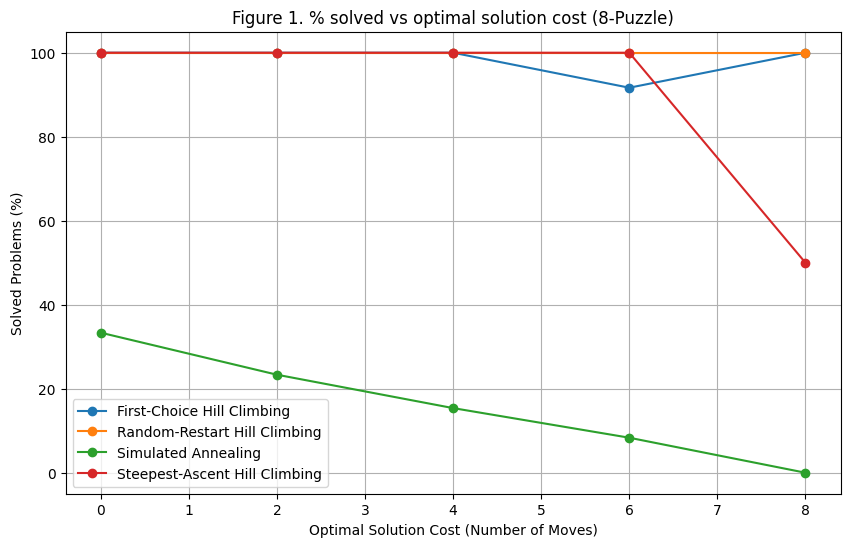

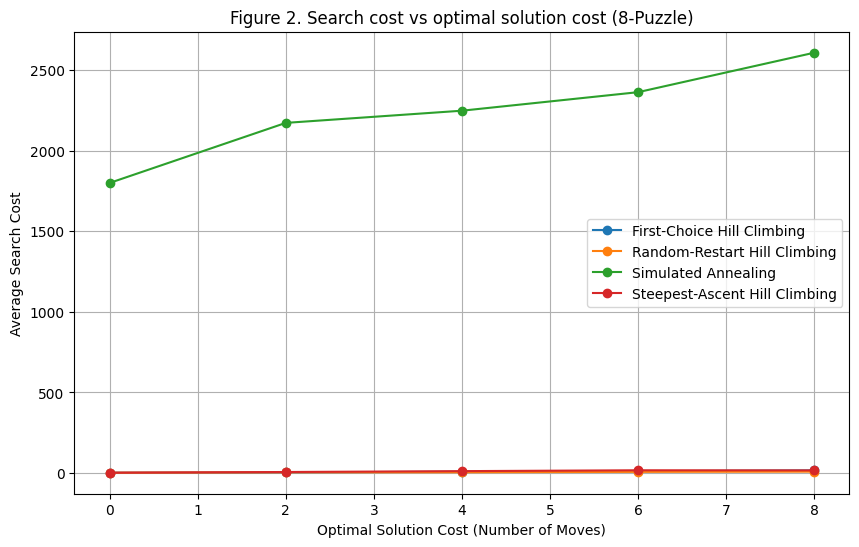


===== 8-Queens Summary Table =====


,Problem,Algorithm,Initial Conflict Count,Solved_Percentage,Average_Search_Cost,Average_Steps,Average_Time,Average_Steps_Solved
0,8-Queens,First-Choice Hill Climbing,4,0.000000,96.000000,3.000000,0.001014,NaN
1,8-Queens,First-Choice Hill Climbing,5,0.000000,79.400000,4.400000,0.001217,NaN
2,8-Queens,First-Choice Hill Climbing,6,0.000000,81.571429,4.428571,0.001269,NaN
3,8-Queens,First-Choice Hill Climbing,7,0.000000,93.857143,5.857143,0.001549,NaN
4,8-Queens,First-Choice Hill Climbing,8,25.000000,92.875000,6.000000,0.001209,6.000000
5,8-Queens,First-Choice Hill Climbing,9,0.000000,107.000000,7.142857,0.001437,NaN
6,8-Queens,First-Choice Hill Climbing,10,0.000000,104.888889,7.000000,0.001609,NaN
7,8-Queens,First-Choice Hill Climbing,11,10.000000,101.900000,7.700000,0.001704,7.000000
8,8-Queens,First-Choice Hill Climbing,12,0.000000,124.000000,8.200000,0.001761,NaN
9,8-Queens,Random-Restart Hill Climbing,4,50.000000,3332.000000,3.500000,0.020742,3.000000


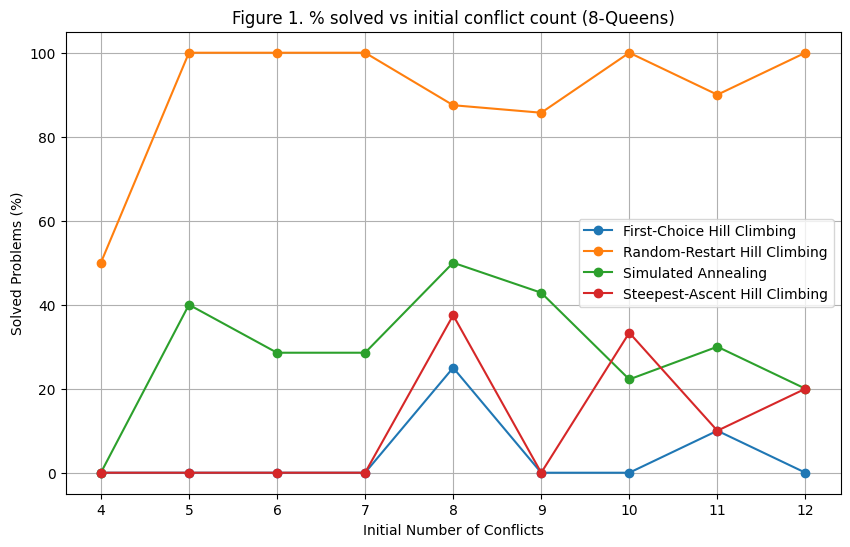

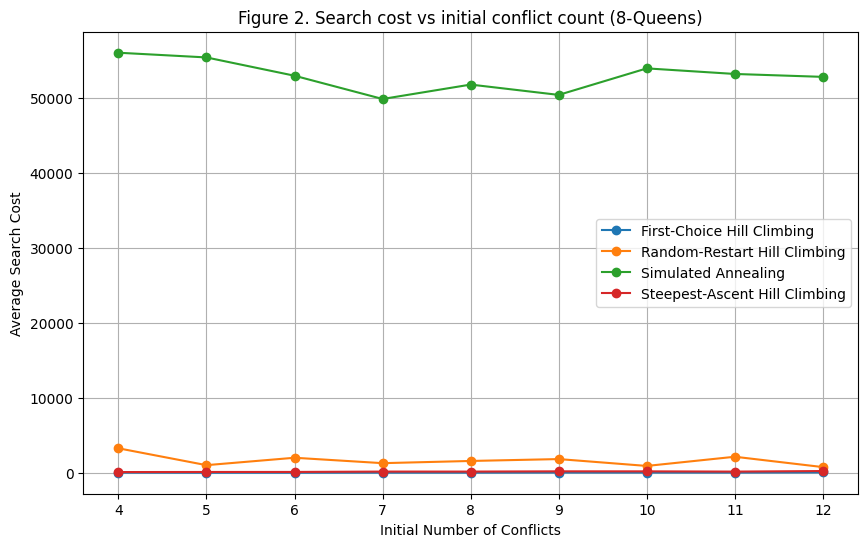

In [ ]:
# 8-PUZZLE RESULTS
analyze_results(puzzle_results, "8-Puzzle")

# 8-QUEENS RESULTS
analyze_results(queen_results, "8-Queens")

# **Report : Project Assignment \#5 - Evaluation of Hill Climbing and Simulated Annealing on 8-Puzzle and 8-Queens**

<br>

**University of Puerto Rico, Mayagüez Campus**  
**Electrical and Computer Engineering Department**

---

<br>

### Prepared by:
Jael A. Gonzalez De Arce  
Néstor O. Santos Torres  
Jayson D. Perez Ramirez  

<br>

### Date:
April 27th, 2026

<br><br><br><br>

---

## Abstract

This project evaluates the performance of several local search algorithms, including steepest-ascent hill climbing, first-choice hill climbing, random-restart hill climbing, and simulated annealing, on the 8-puzzle and 8-queens problems. A large set of problem instances was generated, and each algorithm was tested in terms of search cost and percentage of solved cases. For the 8-puzzle, optimal solution costs were computed using A* search with the Manhattan distance heuristic, while for the 8-queens problem, initial conflict counts were used as a measure of difficulty. The results demonstrate that simple hill climbing methods often fail due to local optima, while random-restart hill climbing significantly improves solution success rates at the cost of increased search effort. Simulated annealing shows moderate performance but incurs high computational cost, highlighting the trade-off between exploration and efficiency.

---

## Table of Contents

I. [Introduction](#i-introduction)

II. [Theory](#ii-theory)

III. [Results and Analysis](#results-and-analysis)

IV. [Conclusion](#conclusion)

[References](#references)

---

## I. Introduction
Local search algorithms operate using a single current state rather than maintaining full search paths, making them suitable for problems with large state spaces and optimization objectives [1]. These methods iteratively improve a candidate solution based on an evaluation function, trading completeness for efficiency.

A common approach is hill climbing, which moves to a neighboring state with a higher value. As described in [1], the algorithm terminates when it reaches a state where no neighbor has a better value. However, this condition may correspond to a local maximum rather than the global optimum, since the search space can contain features such as local maxima, plateaus, and ridges [2]. Variants such as steepest-ascent and first-choice hill climbing differ in how neighbors are evaluated, while random-restart hill climbing improves robustness by performing multiple independent runs.

To address these limitations, simulated annealing introduces a probabilistic mechanism that allows occasional transitions to worse states, reducing the likelihood of getting trapped in local optima. The probability of accepting such moves decreases over time according to a cooling schedule, balancing exploration and exploitation [1], [3].

In this experiment, these algorithms are applied to the 8-puzzle and 8-queens problems, which exhibit different search landscape characteristics. Multiple instances are generated and solved using each algorithm, and performance is evaluated in terms of search cost, number of steps, execution time, and percentage of solved instances, analyzed with respect to the optimal solution cost.

---

## II. Theory

### Local Search Algorithms

Local search algorithms operate by iteratively improving a single candidate solution based on an evaluation function, rather than exploring complete paths in the search space [1]. These methods are particularly effective for large optimization problems where maintaining full search trees is computationally expensive.

- **Steepest-Ascent Hill Climbing:**  
This algorithm evaluates all neighboring states and selects the one that provides the greatest improvement in the objective function. While efficient, it is prone to becoming trapped in local optima, plateaus, and ridges.

- **First-Choice Hill Climbing:**  
Instead of evaluating all neighbors, this variant selects the first neighboring state that improves the current solution. This reduces computational effort per iteration but may lead to less informed decisions and similar susceptibility to local optima.

- **Random-Restart Hill Climbing:**  
This approach repeatedly applies hill climbing from different randomly generated initial states. By performing multiple independent searches, it increases the probability of escaping local optima and reaching a global optimum.

- **Simulated Annealing:**  
Simulated annealing introduces randomness by allowing occasional transitions to worse states with a probability that decreases over time according to a temperature schedule. This enables the algorithm to escape local optima and explore the search space more effectively, balancing exploration and exploitation [3].

### Problem Formulations

For the 8-puzzle problem, the evaluation function is based on the Manhattan distance heuristic, which estimates the number of moves required to reach the goal state. The optimal solution cost corresponds to the minimum number of moves, computed using the A* search algorithm.

For the 8-queens problem, the evaluation function is defined as the negative number of conflicting queen pairs. Since computing the true optimal solution cost would require exhaustive search, the initial number of conflicts is used as a measure of problem difficulty. This provides a consistent and computationally efficient basis for comparison across instances.

---

## III. Results and Analysis

### **Methodology**

The experiments were conducted by generating multiple instances of the 8-puzzle and 8-queens problems and applying different local search algorithms to each instance. For the 8-puzzle, initial states were generated by applying a fixed number of random moves from the goal state to ensure solvability. The optimal solution cost for each instance was computed using the A* search algorithm with the Manhattan distance heuristic.

For the 8-queens problem, random initial configurations were generated, and the number of conflicting queen pairs was used as a measure of problem difficulty.

Four local search algorithms were evaluated: steepest-ascent hill climbing, first-choice hill climbing, random-restart hill climbing, and simulated annealing. Each algorithm was instrumented to record performance metrics, including whether a solution was found, the total search cost (measured as the number of expanded states), the number of steps taken, and execution time.

For each problem instance, all algorithms were executed independently, and their results were recorded. The collected data was aggregated into structured tables to compute average performance metrics and success rates across different levels of problem difficulty.

The results for the 8-puzzle problem are summarized in Table 1, and the results for the 8-queens problem are summarized in Table 2.

|    |  Problem |                     Algorithm | Optimal Solution Cost | Solved_Percentage | Average_Search_Cost | Average_Steps | Average_Time | Average_Steps_Solved |
|---:|---------:|------------------------------:|----------------------:|------------------:|--------------------:|--------------:|-------------:|---------------------:|
|  0 | 8-Puzzle |    First-Choice Hill Climbing |                     0 |        100.000000 |            2.000000 |      1.000000 |     0.000029 |             1.000000 |
|  1 | 8-Puzzle |    First-Choice Hill Climbing |                     2 |        100.000000 |            4.066667 |      2.000000 |     0.000043 |             2.000000 |
|  2 | 8-Puzzle |    First-Choice Hill Climbing |                     4 |        100.000000 |            8.230769 |      4.000000 |     0.000078 |             4.000000 |
|  3 | 8-Puzzle |    First-Choice Hill Climbing |                     6 |         91.666667 |           11.333333 |      5.750000 |     0.000107 |             6.000000 |
|  4 | 8-Puzzle |    First-Choice Hill Climbing |                     8 |        100.000000 |           16.500000 |      8.000000 |     0.000148 |             8.000000 |
|  5 | 8-Puzzle |  Random-Restart Hill Climbing |                     0 |        100.000000 |            2.000000 |      1.000000 |     0.000031 |             1.000000 |
|  6 | 8-Puzzle |  Random-Restart Hill Climbing |                     2 |        100.000000 |            4.400000 |      1.666667 |     0.000058 |             1.666667 |
|  7 | 8-Puzzle |  Random-Restart Hill Climbing |                     4 |        100.000000 |            4.846154 |      1.923077 |     0.000059 |             1.923077 |
|  8 | 8-Puzzle |  Random-Restart Hill Climbing |                     6 |        100.000000 |            7.250000 |      2.500000 |     0.000080 |             2.500000 |
|  9 | 8-Puzzle |  Random-Restart Hill Climbing |                     8 |        100.000000 |            8.500000 |      3.000000 |     0.000096 |             3.000000 |
| 10 | 8-Puzzle |           Simulated Annealing |                     0 |         33.333333 |         1800.000000 |    694.333333 |     0.009619 |            83.000000 |
| 11 | 8-Puzzle |           Simulated Annealing |                     2 |         23.333333 |         2172.633333 |    807.233333 |     0.010609 |           173.857143 |
| 12 | 8-Puzzle |           Simulated Annealing |                     4 |         15.384615 |         2248.230769 |    848.923077 |     0.010897 |            18.000000 |
| 13 | 8-Puzzle |           Simulated Annealing |                     6 |          8.333333 |         2363.166667 |    918.166667 |     0.011779 |            18.000000 |
| 14 | 8-Puzzle |           Simulated Annealing |                     8 |          0.000000 |         2608.000000 |   1000.000000 |     0.012980 |                  NaN |
| 15 | 8-Puzzle | Steepest-Ascent Hill Climbing |                     0 |        100.000000 |            2.000000 |      1.000000 |     0.000032 |             1.000000 |
| 16 | 8-Puzzle | Steepest-Ascent Hill Climbing |                     2 |        100.000000 |            6.466667 |      2.000000 |     0.000072 |             2.000000 |
| 17 | 8-Puzzle | Steepest-Ascent Hill Climbing |                     4 |        100.000000 |           11.846154 |      4.000000 |     0.000112 |             4.000000 |
| 18 | 8-Puzzle | Steepest-Ascent Hill Climbing |                     6 |        100.000000 |           17.166667 |      6.000000 |     0.000156 |             6.000000 |
| 19 | 8-Puzzle | Steepest-Ascent Hill Climbing |                     8 |         50.000000 |           16.500000 |      5.500000 |     0.000149 |             8.000000 |

Table 1. Summary of performance metrics for local search algorithms on the 8-puzzle problem.

<br>


|    |  Problem |                     Algorithm | Initial Conflict Count | Solved_Percentage | Average_Search_Cost | Average_Steps | Average_Time | Average_Steps_Solved |
|---:|---------:|------------------------------:|-----------------------:|------------------:|--------------------:|--------------:|-------------:|---------------------:|
|  0 | 8-Queens |    First-Choice Hill Climbing |                      4 |          0.000000 |           96.000000 |      3.000000 |     0.001014 |                  NaN |
|  1 | 8-Queens |    First-Choice Hill Climbing |                      5 |          0.000000 |           79.400000 |      4.400000 |     0.001217 |                  NaN |
|  2 | 8-Queens |    First-Choice Hill Climbing |                      6 |          0.000000 |           81.571429 |      4.428571 |     0.001269 |                  NaN |
|  3 | 8-Queens |    First-Choice Hill Climbing |                      7 |          0.000000 |           93.857143 |      5.857143 |     0.001549 |                  NaN |
|  4 | 8-Queens |    First-Choice Hill Climbing |                      8 |         25.000000 |           92.875000 |      6.000000 |     0.001209 |             6.000000 |
|  5 | 8-Queens |    First-Choice Hill Climbing |                      9 |          0.000000 |          107.000000 |      7.142857 |     0.001437 |                  NaN |
|  6 | 8-Queens |    First-Choice Hill Climbing |                     10 |          0.000000 |          104.888889 |      7.000000 |     0.001609 |                  NaN |
|  7 | 8-Queens |    First-Choice Hill Climbing |                     11 |         10.000000 |          101.900000 |      7.700000 |     0.001704 |             7.000000 |
|  8 | 8-Queens |    First-Choice Hill Climbing |                     12 |          0.000000 |          124.000000 |      8.200000 |     0.001761 |                  NaN |
|  9 | 8-Queens |  Random-Restart Hill Climbing |                      4 |         50.000000 |         3332.000000 |      3.500000 |     0.020742 |             3.000000 |
| 10 | 8-Queens |  Random-Restart Hill Climbing |                      5 |        100.000000 |         1086.400000 |      3.600000 |     0.008550 |             3.600000 |
| 11 | 8-Queens |  Random-Restart Hill Climbing |                      6 |        100.000000 |         2072.000000 |      3.714286 |     0.016513 |             3.714286 |
| 12 | 8-Queens |  Random-Restart Hill Climbing |                      7 |        100.000000 |         1352.000000 |      4.285714 |     0.012500 |             4.285714 |
| 13 | 8-Queens |  Random-Restart Hill Climbing |                      8 |         87.500000 |         1645.000000 |      4.375000 |     0.013350 |             4.285714 |
| 14 | 8-Queens |  Random-Restart Hill Climbing |                      9 |         85.714286 |         1896.000000 |      4.142857 |     0.012599 |             4.000000 |
| 15 | 8-Queens |  Random-Restart Hill Climbing |                     10 |        100.000000 |          983.111111 |      3.888889 |     0.007746 |             3.888889 |
| 16 | 8-Queens |  Random-Restart Hill Climbing |                     11 |         90.000000 |         2206.400000 |      3.800000 |     0.018572 |             3.666667 |
| 17 | 8-Queens |  Random-Restart Hill Climbing |                     12 |        100.000000 |          828.800000 |      4.600000 |     0.005795 |             4.600000 |
| 18 | 8-Queens |           Simulated Annealing |                      4 |          0.000000 |        56000.000000 |   1000.000000 |     0.058744 |                  NaN |
| 19 | 8-Queens |           Simulated Annealing |                      5 |         40.000000 |        55372.800000 |    988.800000 |     0.071440 |           972.000000 |
| 20 | 8-Queens |           Simulated Annealing |                      6 |         28.571429 |        52936.000000 |    945.285714 |     0.072162 |           808.500000 |
| 21 | 8-Queens |           Simulated Annealing |                      7 |         28.571429 |        49840.000000 |    890.000000 |     0.063627 |           615.000000 |
| 22 | 8-Queens |           Simulated Annealing |                      8 |         50.000000 |        51758.000000 |    924.250000 |     0.071355 |           848.500000 |
| 23 | 8-Queens |           Simulated Annealing |                      9 |         42.857143 |        50384.000000 |    899.714286 |     0.071244 |           766.000000 |
| 24 | 8-Queens |           Simulated Annealing |                     10 |         22.222222 |        53915.555556 |    962.777778 |     0.072466 |           832.500000 |
| 25 | 8-Queens |           Simulated Annealing |                     11 |         30.000000 |        53172.000000 |    949.500000 |     0.078419 |           831.666667 |
| 26 | 8-Queens |           Simulated Annealing |                     12 |         20.000000 |        52785.600000 |    942.600000 |     0.063243 |           713.000000 |
| 27 | 8-Queens | Steepest-Ascent Hill Climbing |                      4 |          0.000000 |          168.000000 |      3.000000 |     0.001081 |                  NaN |
| 28 | 8-Queens | Steepest-Ascent Hill Climbing |                      5 |          0.000000 |          179.200000 |      3.200000 |     0.001559 |                  NaN |
| 29 | 8-Queens | Steepest-Ascent Hill Climbing |                      6 |          0.000000 |          184.000000 |      3.285714 |     0.001466 |                  NaN |
| 30 | 8-Queens | Steepest-Ascent Hill Climbing |                      7 |          0.000000 |          232.000000 |      4.142857 |     0.001907 |                  NaN |
| 31 | 8-Queens | Steepest-Ascent Hill Climbing |                      8 |         37.500000 |          231.000000 |      4.125000 |     0.001622 |             4.333333 |
| 32 | 8-Queens | Steepest-Ascent Hill Climbing |                      9 |          0.000000 |          264.000000 |      4.714286 |     0.001905 |                  NaN |
| 33 | 8-Queens | Steepest-Ascent Hill Climbing |                     10 |         33.333333 |          261.333333 |      4.666667 |     0.002170 |             4.333333 |
| 34 | 8-Queens | Steepest-Ascent Hill Climbing |                     11 |         10.000000 |          229.600000 |      4.100000 |     0.002020 |             4.000000 |
| 35 | 8-Queens | Steepest-Ascent Hill Climbing |                     12 |         20.000000 |          302.400000 |      5.400000 |     0.002259 |             6.000000 |

Table 2. Summary of performance metrics for local search algorithms on the 8-queens problem.

Additionally, performance trends were visualized through plots showing the percentage of solved instances and the average search cost as functions of the optimal solution cost.

The results demonstrate clear differences in the performance of the evaluated local search algorithms across both problem domains.


### **8-Puzzle Analysis**

Figure 1 shows the percentage of solved instances as a function of the optimal solution cost for the 8-puzzle problem.

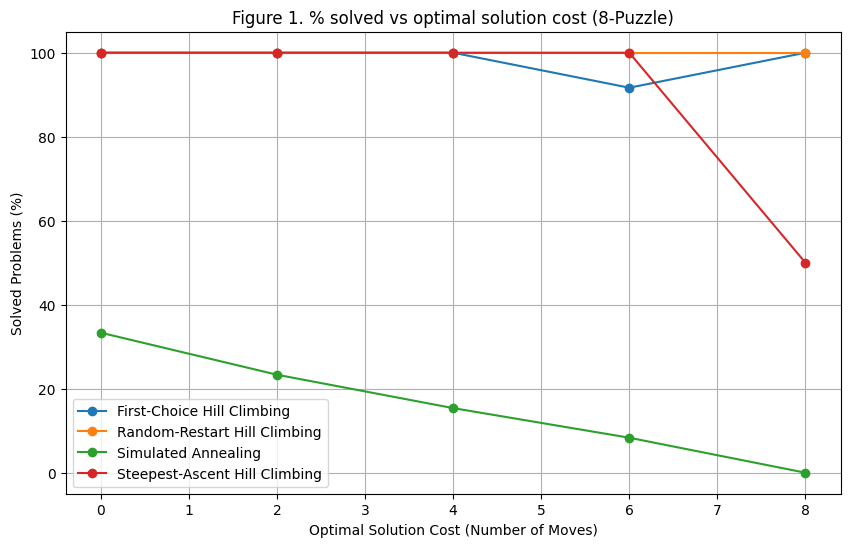

Figure 1. Percentage of solved instances vs. optimal solution cost for the 8-puzzle problem.

As shown in Figure 1, both steepest-ascent hill climbing and first-choice hill climbing achieve high success rates for lower optimal solution costs, but their performance begins to degrade as the problem becomes more difficult. In particular, steepest-ascent hill climbing drops to approximately 50% success at higher depths, indicating its susceptibility to local maxima.

Random-restart hill climbing maintains a 100% success rate across all tested difficulty levels, as also reflected in Table 1. This behavior is expected, since multiple restarts increase the probability of escaping local optima.

Figure 2 shows the average search cost as a function of the optimal solution cost.

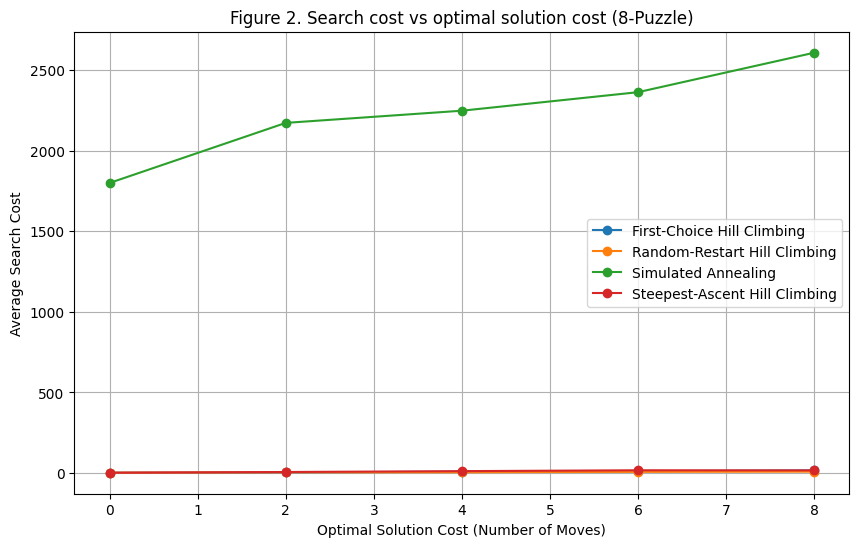

Figure 2. Average search cost vs. optimal solution cost for the 8-puzzle problem.

As observed in Figure 2, random-restart hill climbing incurs a higher search cost compared to single-run hill climbing methods due to repeated restarts. Simulated annealing exhibits significantly higher search costs, often approaching the maximum number of allowed steps, while also achieving low success rates. This suggests inefficient exploration caused by the chosen cooling schedule.

### **8-Queens Analysis**

Figure 3 presents the percentage of solved instances for the 8-queens problem.

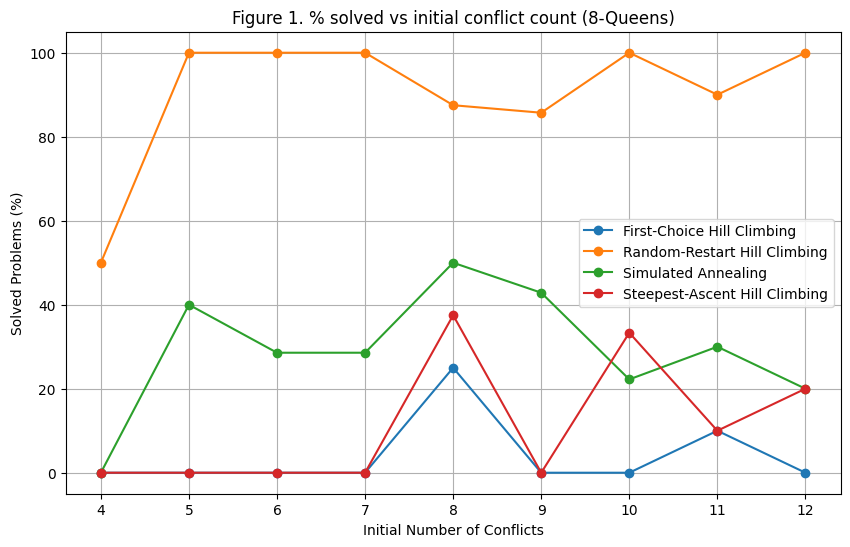

Figure 3. Percentage of solved instances vs. problem difficulty for the 8-queens problem.

As shown in Figure 3, both steepest-ascent and first-choice hill climbing perform poorly, with success rates close to 0% for most difficulty levels. This reflects the presence of many local optima in the search space, which prevents these algorithms from reaching valid solutions.

Random-restart hill climbing significantly outperforms the other methods, achieving high success rates across most difficulty levels, as also indicated in Table 2.

Figure 4 shows the average search cost for the 8-queens problem.

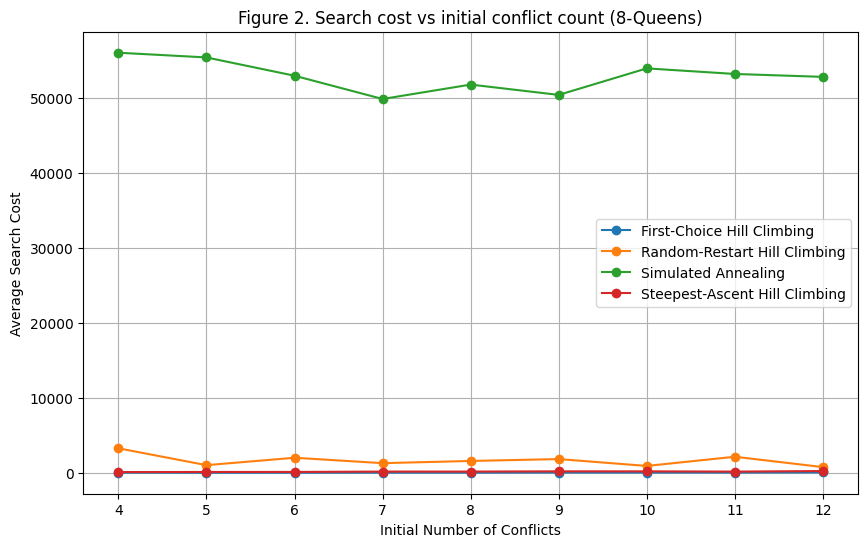

Figure 4. Average search cost vs. problem difficulty for the 8-queens problem.

As observed in Figure 4, random-restart hill climbing achieves high reliability but at the cost of significantly increased search effort. Simulated annealing achieves moderate success rates but incurs extremely high search costs, often reaching tens of thousands of expansions, indicating a trade-off between exploration and efficiency.

---

## IV. Conclusion

This study evaluated the performance of several local search algorithms on the 8-puzzle and 8-queens problems, focusing on their efficiency and reliability across varying levels of problem difficulty. The results show that algorithm performance is strongly influenced by the structure of the search space.

For the 8-puzzle problem, hill climbing methods performed well for lower difficulty levels but exhibited decreased reliability as the optimal solution cost increased. In contrast, random-restart hill climbing consistently achieved high success rates across all instances, demonstrating its effectiveness in overcoming local optima. However, this improvement came at the cost of increased search effort.

For the 8-queens problem, the limitations of basic hill climbing methods became more pronounced, with both steepest-ascent and first-choice variants failing to solve most instances due to the large number of local optima. Random-restart hill climbing again proved to be the most reliable approach, while simulated annealing achieved moderate success but required significantly higher computational cost.

Overall, the results highlight a fundamental trade-off in local search algorithms between computational efficiency and solution reliability. While simple hill climbing methods are fast, they are not robust in complex search spaces. Techniques such as random restart and simulated annealing improve the likelihood of finding solutions but introduce additional computational overhead. Among the evaluated methods, random-restart hill climbing provides the most consistent performance across both problems, achieving the highest success rates while maintaining reasonable computational cost. In contrast, basic hill climbing methods are efficient but unreliable, and simulated annealing, while capable of escaping local optima, requires careful parameter tuning to achieve competitive performance.

These findings emphasize the importance of selecting appropriate search strategies based on the characteristics of the problem and the desired balance between efficiency and robustness.

---

## References

[1] S. Russell and P. Norvig, Artificial Intelligence: A Modern Approach, 4th ed., Pearson, 2021.

[2] GeeksforGeeks, “Hill Climbing in Artificial Intelligence.”
https://www.geeksforgeeks.org/artificial-intelligence/introduction-hill-climbing-artificial-intelligence/

[3] Wikipedia, “Simulated Annealing.”
https://en.wikipedia.org/wiki/Simulated_annealing

[4] N. G. Santiago and M. A. Jiménez, "Writing Formal Reports," Univ. of Puerto Rico, 2002.

[5] UC Berkeley, “AIMA Python Code Repository,” [Online]. Available: https://github.com/aimacode/aima-python.  

## Disclaimer

**Use of AI Tools:** Large language models (LLMs), specifically ChatGPT, were used to assist with grammar refinement, clarity of explanations, and verification of concepts. All generated content was reviewed, validated, and adapted by the author to ensure accuracy and alignment with course material.